In [ ]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Fitting
from scipy.optimize import curve_fit

# Image Analysis Specific Imports
from skimage.measure import perimeter, euler_number
from scipy.ndimage import rotate

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# GRF
from GRF import generate_gaussian_random_field

# 2D Gaussian
from Gaussian import generate_2d_gaussian

# Sierpinski Triangle
from Sierpinski_Triangle import generate_sierpinski_triangle

# Visualization Tools
from visualization_tools import show_shapes_results, plot_


[15:51:21] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=280373;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=415047;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

# 📌 **Simulations with Simple Geometrical/Topological Features**
---
As discussed mutliple times, in order to understand better the quirks and advantages of the Perimeter-Area method, we should apply it to very simple shapes. In this Jupyter Notebook we will also compare the results to another method for the calculation of the fractal dimension, namely the Box-Counting Method.

## **1: A 1D Line**
---
A one dimensional line should return a (fractal) dimension of **D = 1**, corresponding to its euclidian dimension. By using the Box-Counting Method, we do obtain this result. However, the Perimeter-Area (PA) relation presents a different picture. This discrepancy arises due to the inherent *anti-correlation* in the PA formula:

$$ A \propto k \cdot P^{2/D} $$

For a line:
- **Area:** $ A = 1 \cdot l $
- **Perimeter:** $ P = l $
- **Proportionality factor:** $ k = 1 $

Substituting these values:

$$ l \propto l^{2/D} $$

Solving for $ D $, we find that the PA method returns **D = 2**, highlighting the built-in anti-correlation of the formula.

c:\Users\User\Documents\GitHub\fractal_OMC\scripts\Minkowski_Fractal_Dimension.py:78: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(filtered_log_perimeters, filtered_log_areas, 1)


1.0006277897773064


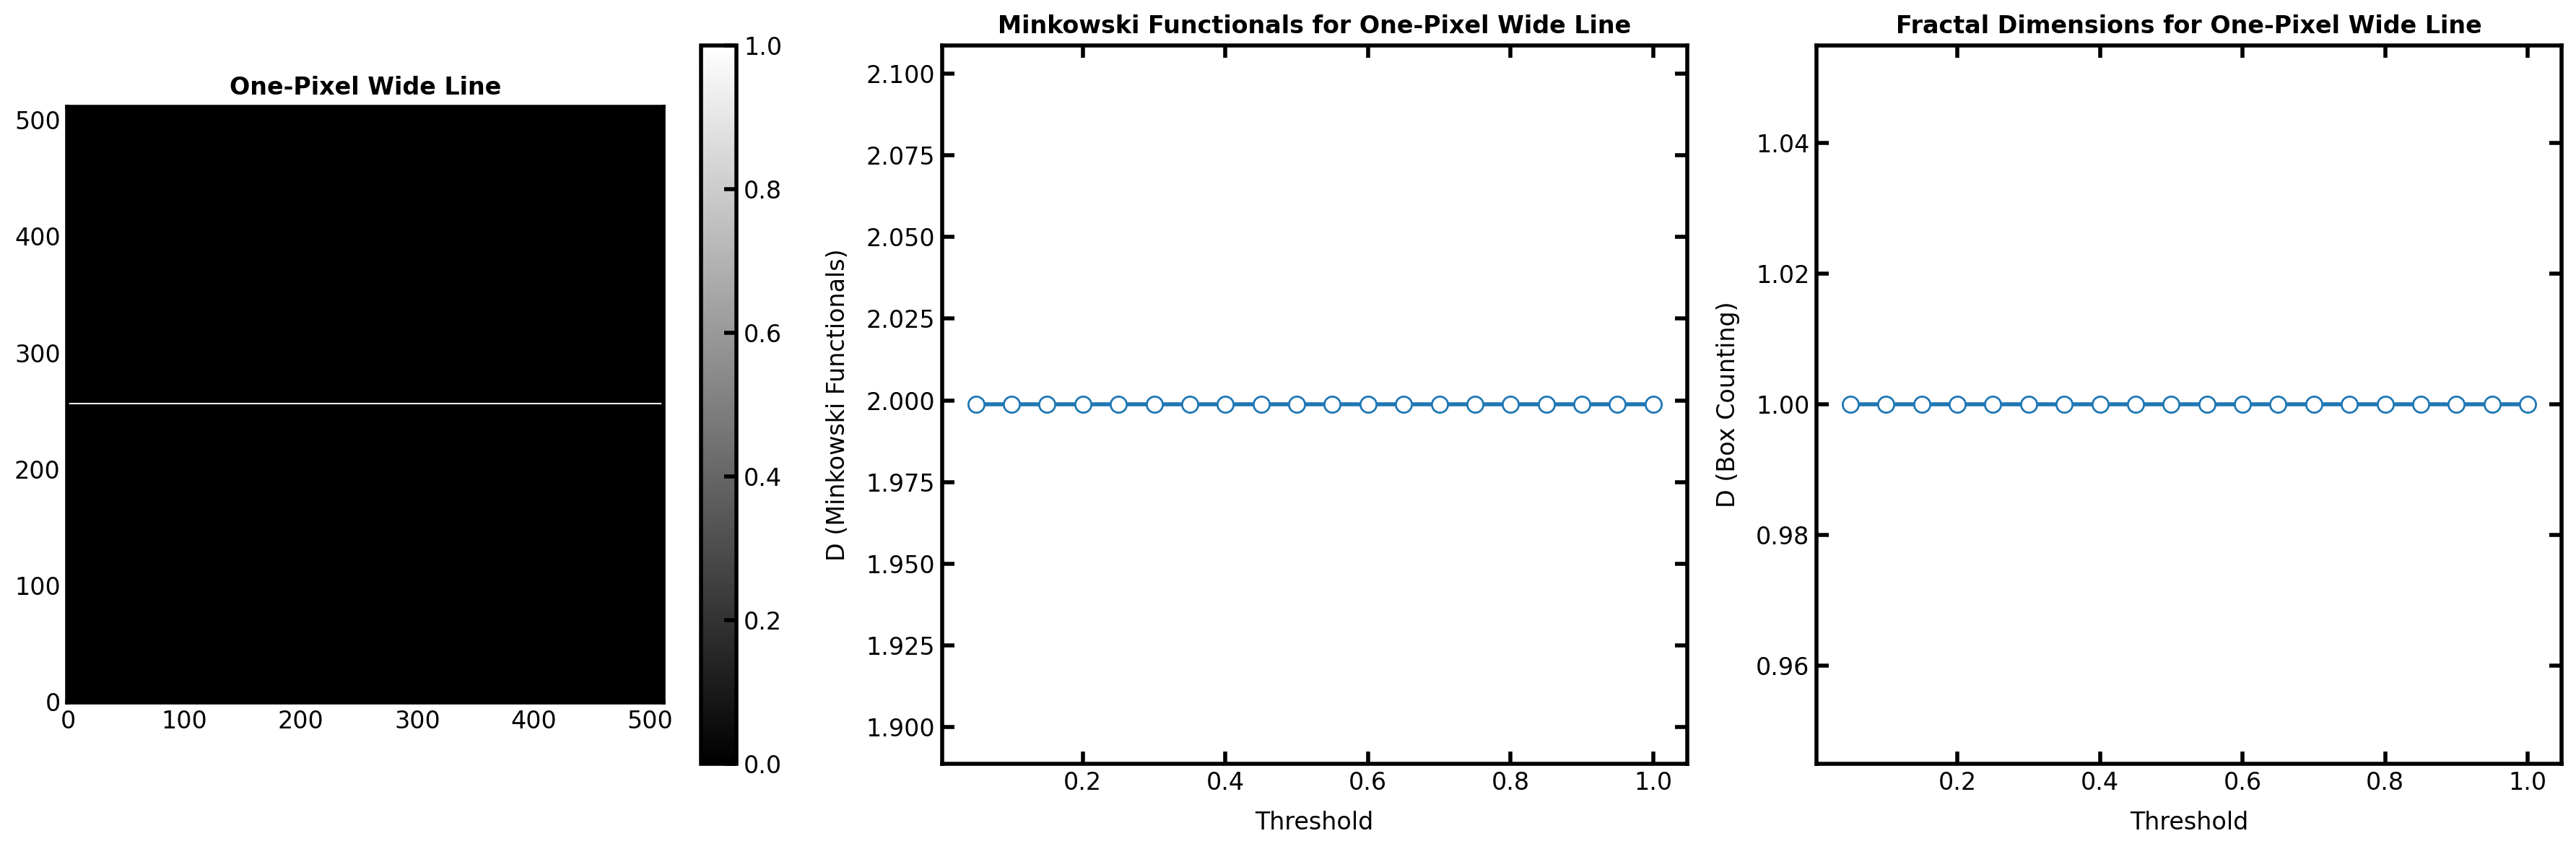

In [2]:
### ONE DIMENSIONAL LINE
shape = (512, 512)
line_image = np.zeros(shape, dtype=bool)
line_image[shape[0] // 2, :] = 1

line_thresholds = np.linspace(0.05, 1, 20)
results = standard_minkowski_functionals(line_image.astype(float), thresholds=line_thresholds)

line_fractal_dimension_BC = []
for threshold in line_thresholds:
    line_fractal_dimension_BC.append(box_counting(line_image >= threshold))

show_shapes_results(line_image, "One-Pixel Wide Line", line_thresholds, results, line_fractal_dimension_BC)

### **Padding**
As it was discussed in one of the progress presentation, the shapes that we are analyzing should not touch the borders of our box, as this tends to influence the results. This could also be seen with an example as easy as a straight line. To this end, a padding is added to all of the shapes.

An interesting fact is that the box counting method is affected by the value of the padding, wheras the PA is not. Let's think about this: 
* We want to have a method that, regardless of how big an object is, it returns a measure of the complexity of the border (hairy caterpillar or sausage? not big or small).
* Scale, Orientation and such should not influence the results.
* This is hence a good indicator for our method.

c:\Users\User\Documents\GitHub\fractal_OMC\scripts\Minkowski_Fractal_Dimension.py:78: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(filtered_log_perimeters, filtered_log_areas, 1)


1.0008088534793889


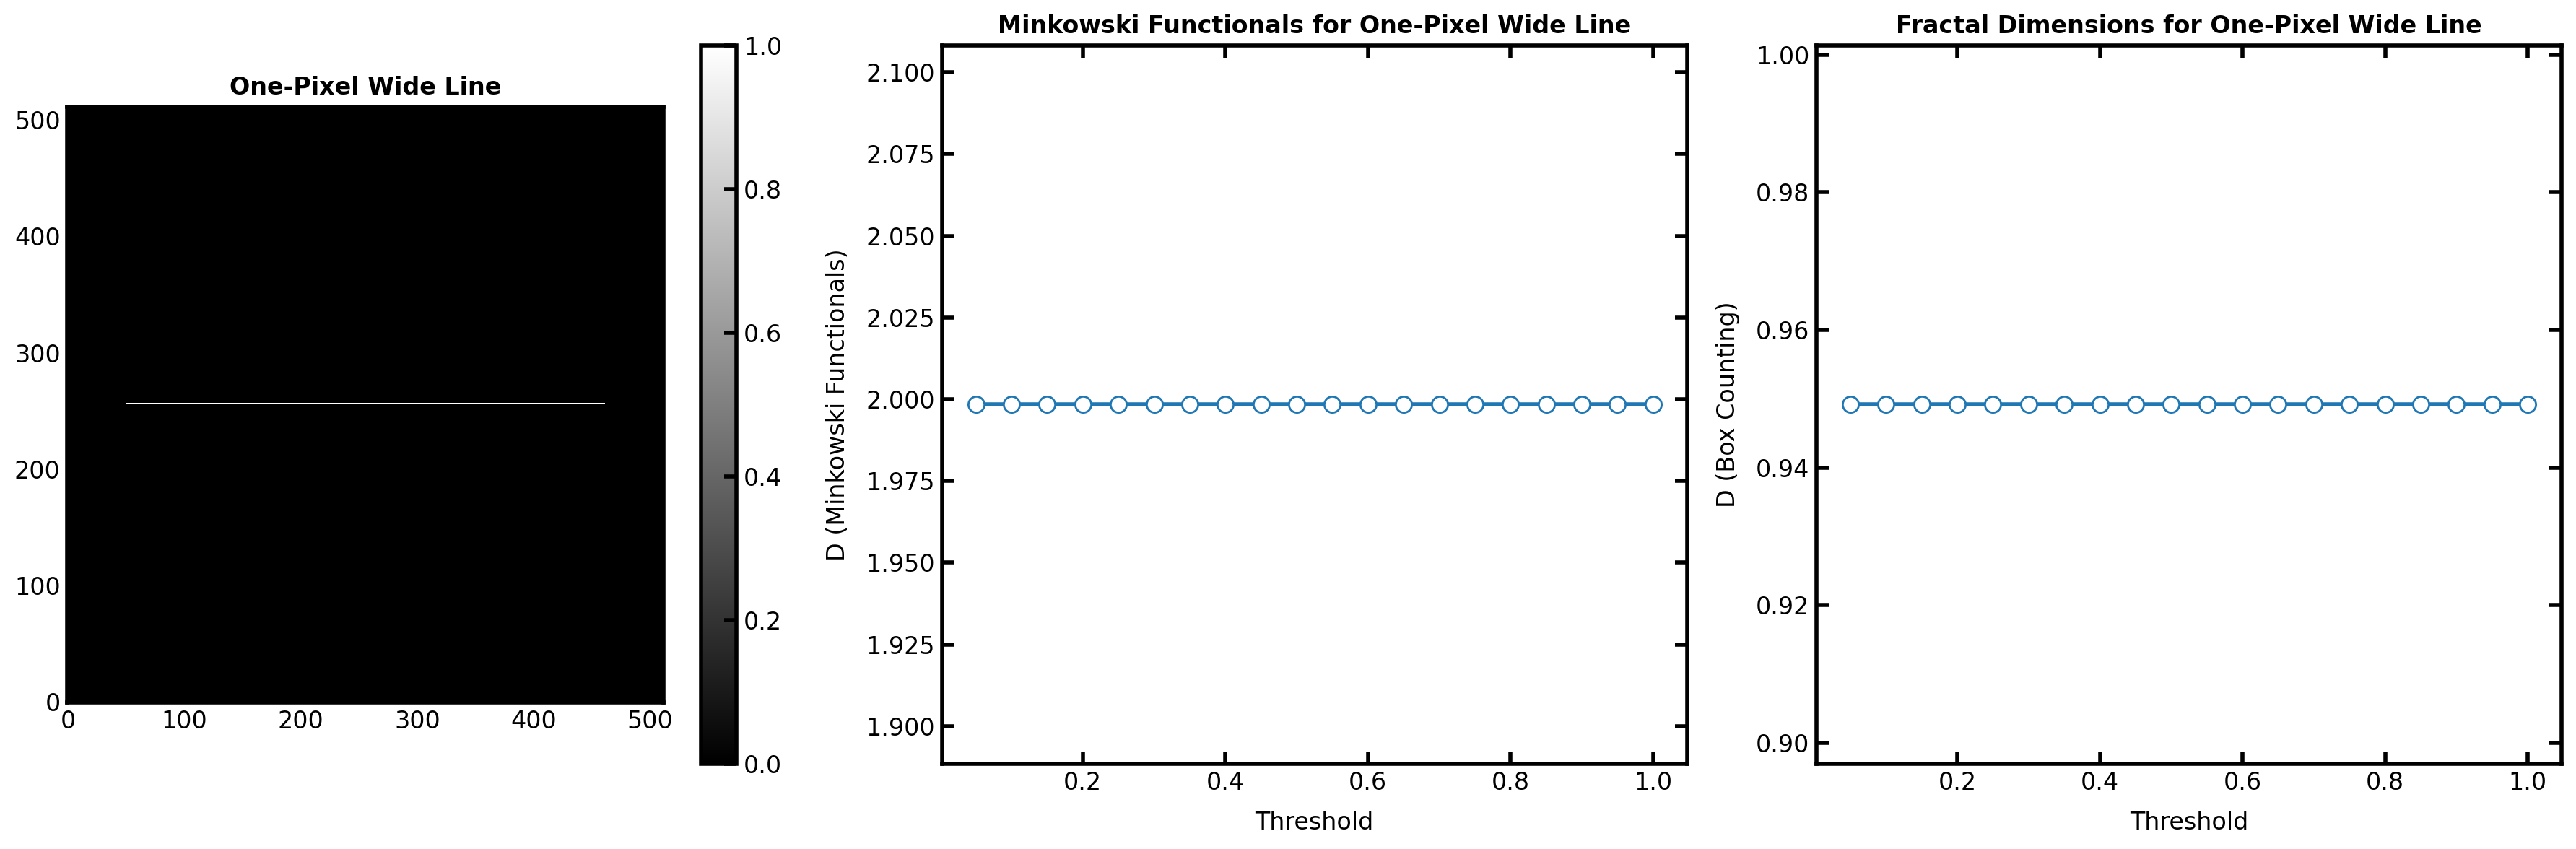

c:\Users\User\Documents\GitHub\fractal_OMC\scripts\Minkowski_Fractal_Dimension.py:78: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(filtered_log_perimeters, filtered_log_areas, 1)


1.0017726862420648


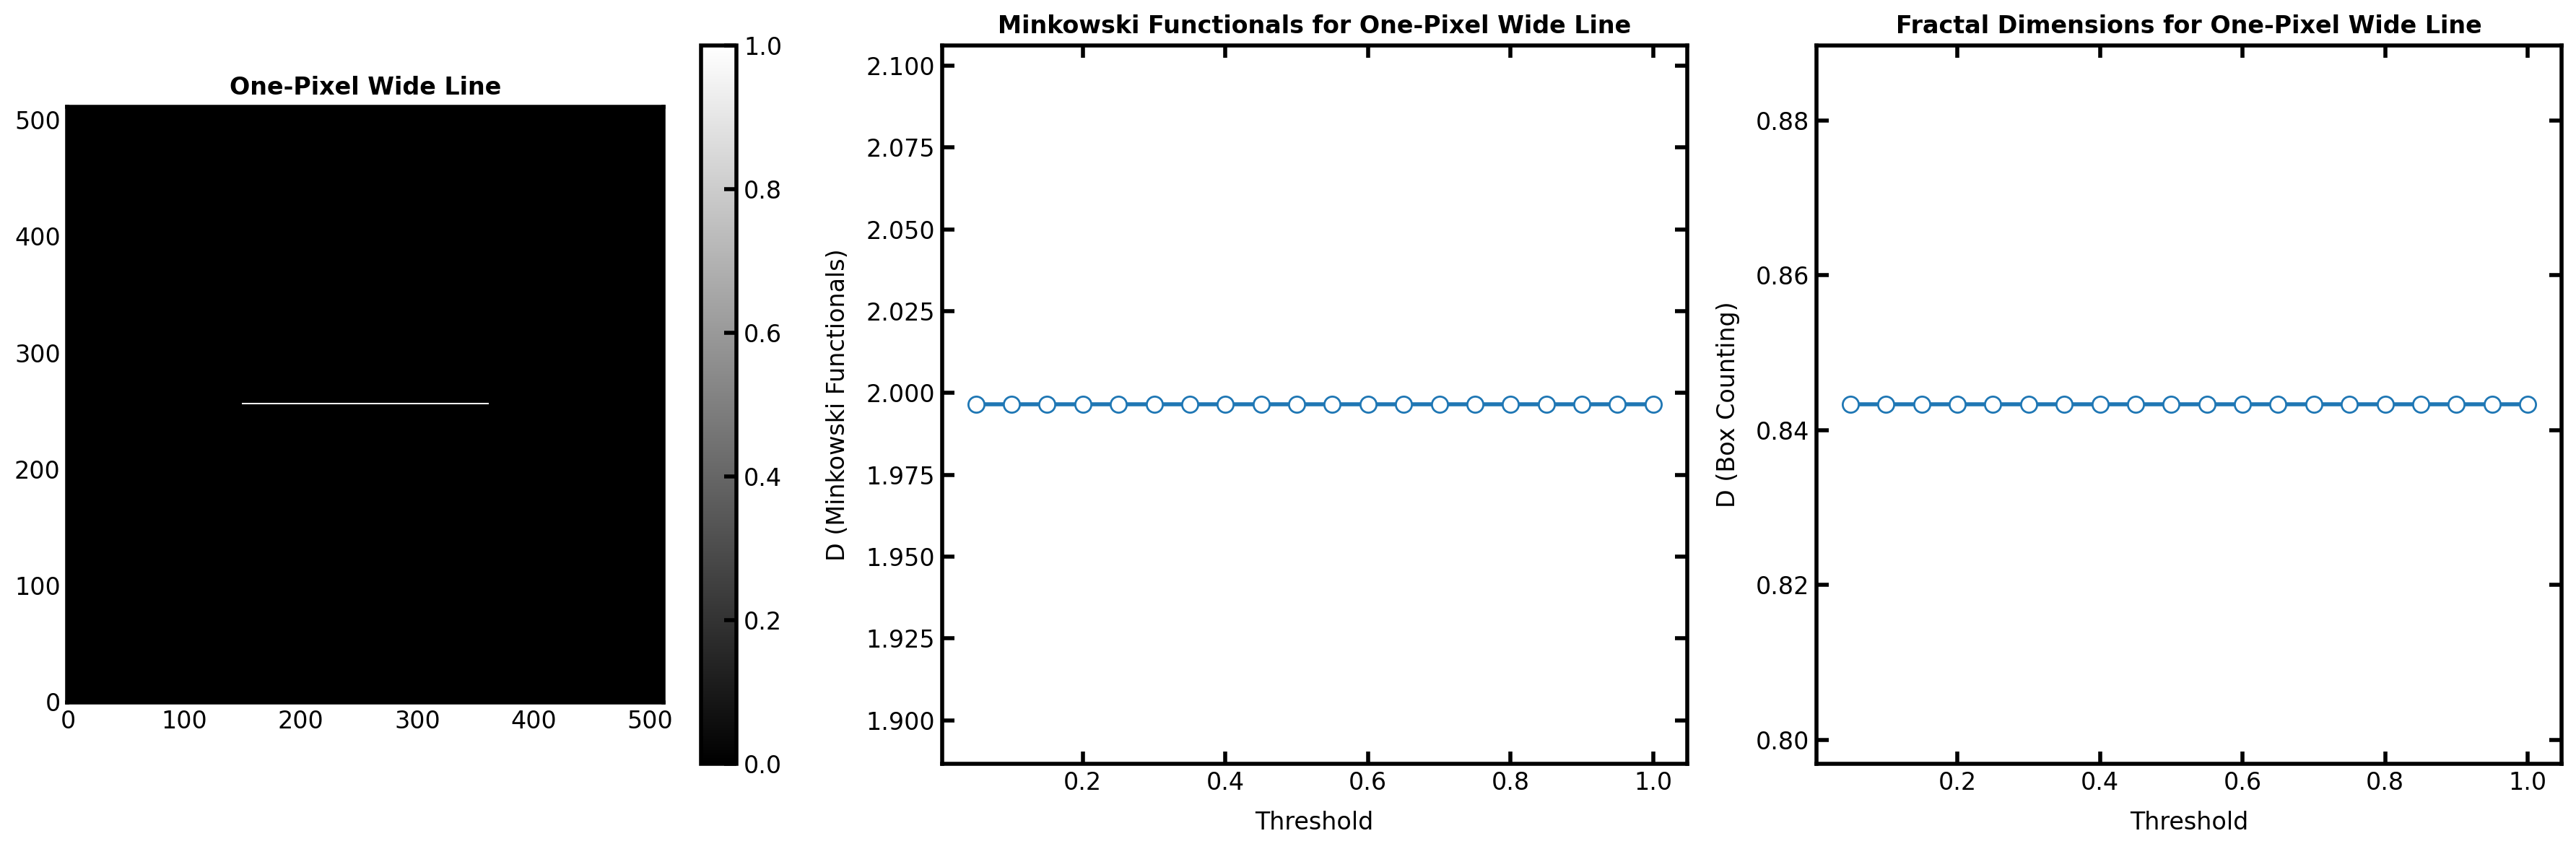

In [3]:
### ONE DIMENSIONAL LINE WITH PADDING
shape = (512, 512)
line_image = np.zeros(shape, dtype=bool)
padding = 50 
line_image[shape[0] // 2, padding:-padding] = 1 

# Calculate Minkowski functionals for the line image
line_thresholds = np.linspace(0.05, 1, 20)
results = standard_minkowski_functionals(line_image.astype(float), thresholds=line_thresholds)

line_fractal_dimension_BC = []
for threshold in line_thresholds:
    line_fractal_dimension_BC.append(box_counting(line_image >= threshold))

show_shapes_results(line_image, "One-Pixel Wide Line", line_thresholds, results, line_fractal_dimension_BC)

line_image = np.zeros(shape, dtype=bool)
padding = 150 
line_image[shape[0] // 2, padding:-padding] = 1

line_thresholds = np.linspace(0.05, 1, 20)
results = standard_minkowski_functionals(line_image.astype(float), thresholds=line_thresholds)

line_fractal_dimension_BC = []
for threshold in line_thresholds:
    line_fractal_dimension_BC.append(box_counting(line_image >= threshold))

show_shapes_results(line_image, "One-Pixel Wide Line", line_thresholds, results, line_fractal_dimension_BC)

### **Orientation**
This should not cause any difference, but we do see some slight differences in both methods. In the PA method we see a small difference of around 0.01, which I belive is due to discretization quirks in the way the line is represented diagonally.

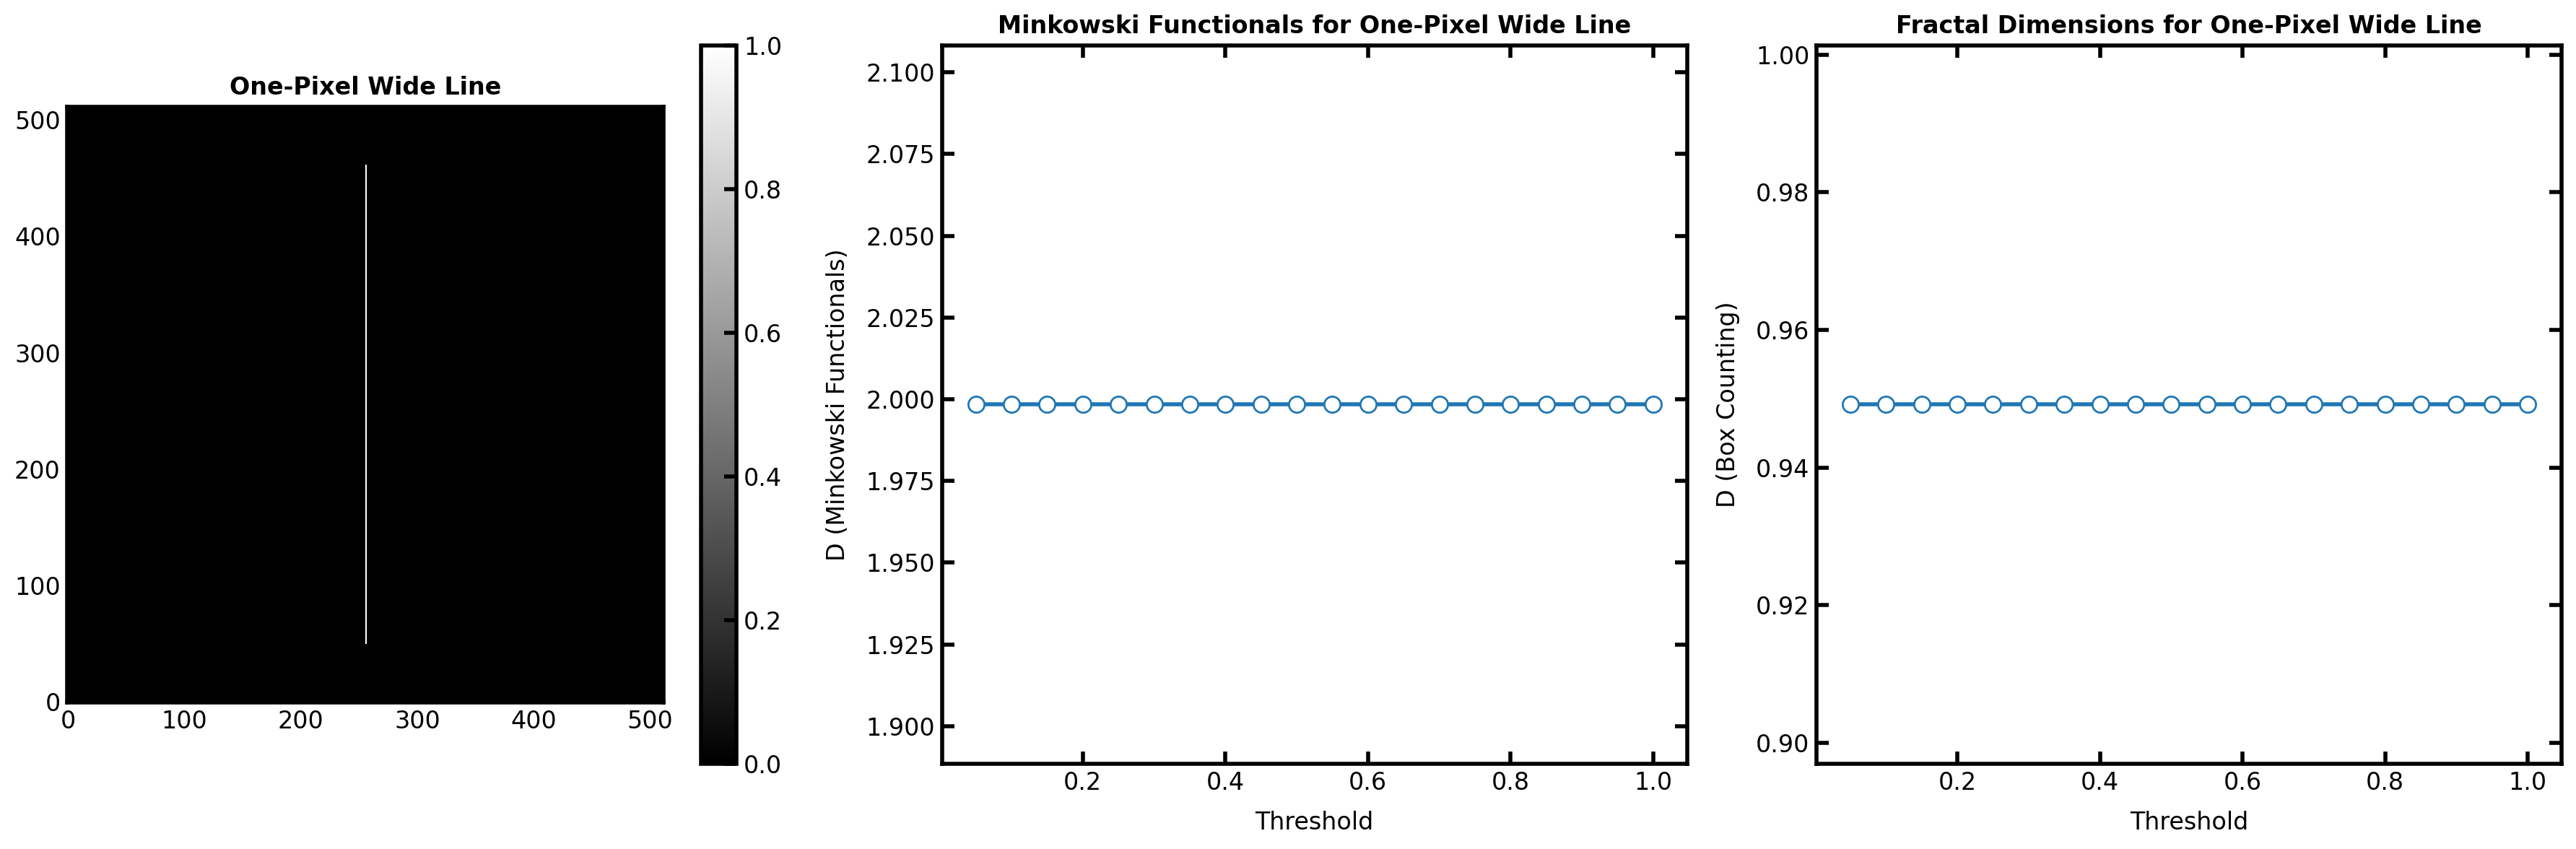

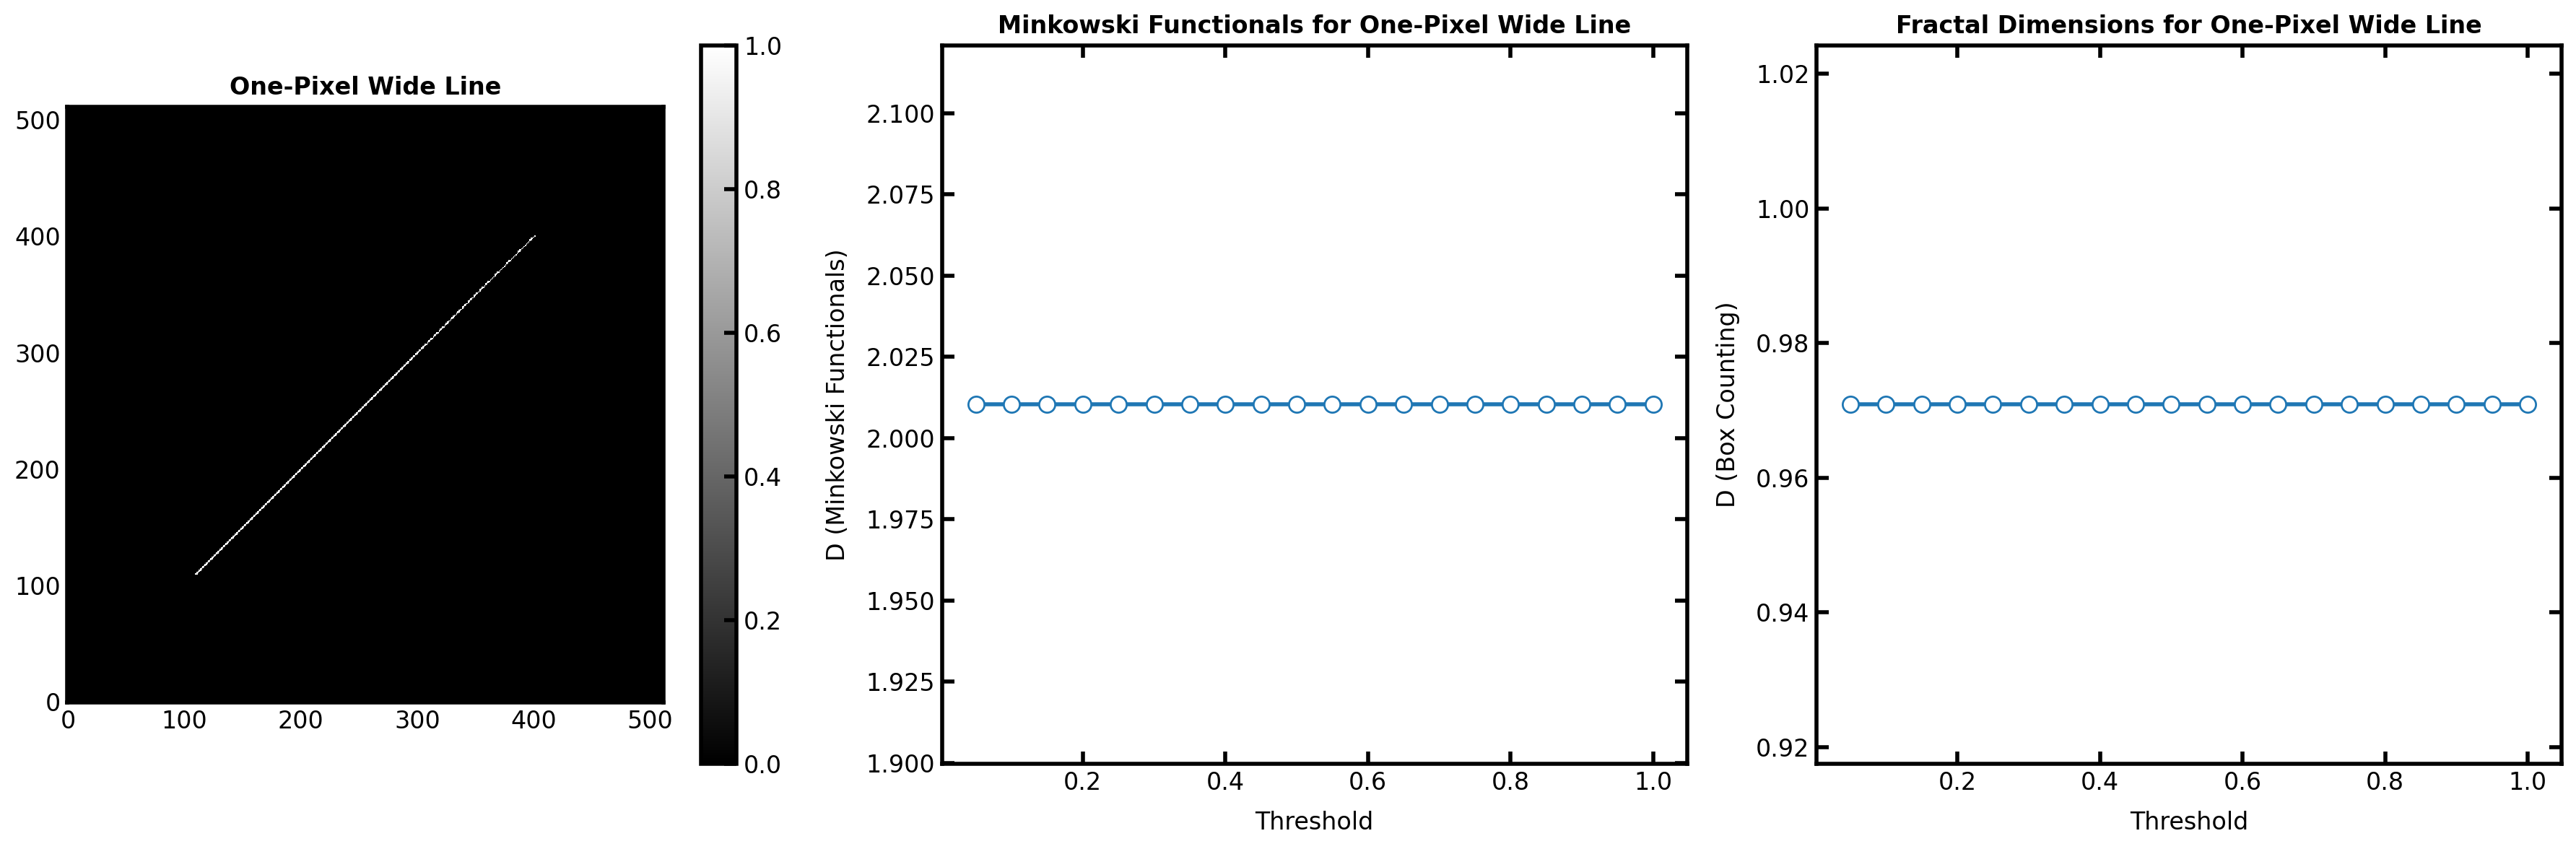

In [4]:
### ONE DIMENSIONAL LINE WITH PADDING AND ROTATION
shape = (512, 512)
line_image = np.zeros(shape, dtype=bool)
padding = 50
line_image[padding:-padding, shape[1] // 2] = 1

line_thresholds = np.linspace(0.05, 1, 20)
results = standard_minkowski_functionals(line_image.astype(float), thresholds=line_thresholds)

line_fractal_dimension_BC = []
for threshold in line_thresholds:
    line_fractal_dimension_BC.append(box_counting(line_image >= threshold))

show_shapes_results(line_image, "One-Pixel Wide Line", line_thresholds, results, line_fractal_dimension_BC)

line_image = np.zeros(shape, dtype=bool)
padding = 50 
line_image[padding:-padding, shape[1] // 2] = 1

# Rotate the line by 45 degrees
line_image = rotate(line_image, angle=45, reshape=False, order=0)

line_thresholds = np.linspace(0.05, 1, 20)
results = standard_minkowski_functionals(line_image.astype(float), thresholds=line_thresholds)

line_fractal_dimension_BC = []
for threshold in line_thresholds:
    line_fractal_dimension_BC.append(box_counting(line_image >= threshold))

show_shapes_results(line_image, "One-Pixel Wide Line", line_thresholds, results, line_fractal_dimension_BC)

### **Line: Summary**
Applying the method to a straight line showed us:
1. the anti-correlation with other methods is built in the Perimeter-Area Relation
2. adding a padding to the simulations is important to avoid artifacts
3. the method seems to be orientation- and scale-independent, altough more tests are needed.

## **2: A Filled Plane**
---

Following the anti-correlation discovered above, for a plane we then expect a (fractal) dimension of **D = 2** with the Box-Counting Method and **D = 1** with the Perimeter-Area (PA) Method. The Box-Counting Method confirms this expectation, but the PA result appears slightly off.

This discrepancy arises because the formula:

$$ A = l^2 $$
$$ P = 4 \cdot l $$

Substituting these values:

$$ l^2 \propto l^{2/D} $$

hence **D = 2** in the PA relation. When substituted into the PA formula, this leads to an unexpected result of around 1.2. However, when using the corrected implementation in `plane_corrected_minkowski_functionals`, which includes the proportionality factor $ k $, we obtain exactly the expected values: **D = 2** for the Box-Counting Method and **D = 1** for the PA Method.

### **Padding**

The padding from the border cause here some differences as well between both methods, with the PA method being less affected (changes in the order of 0.05) with respect to the box counting method (changes in the order of 0.1-0.2)

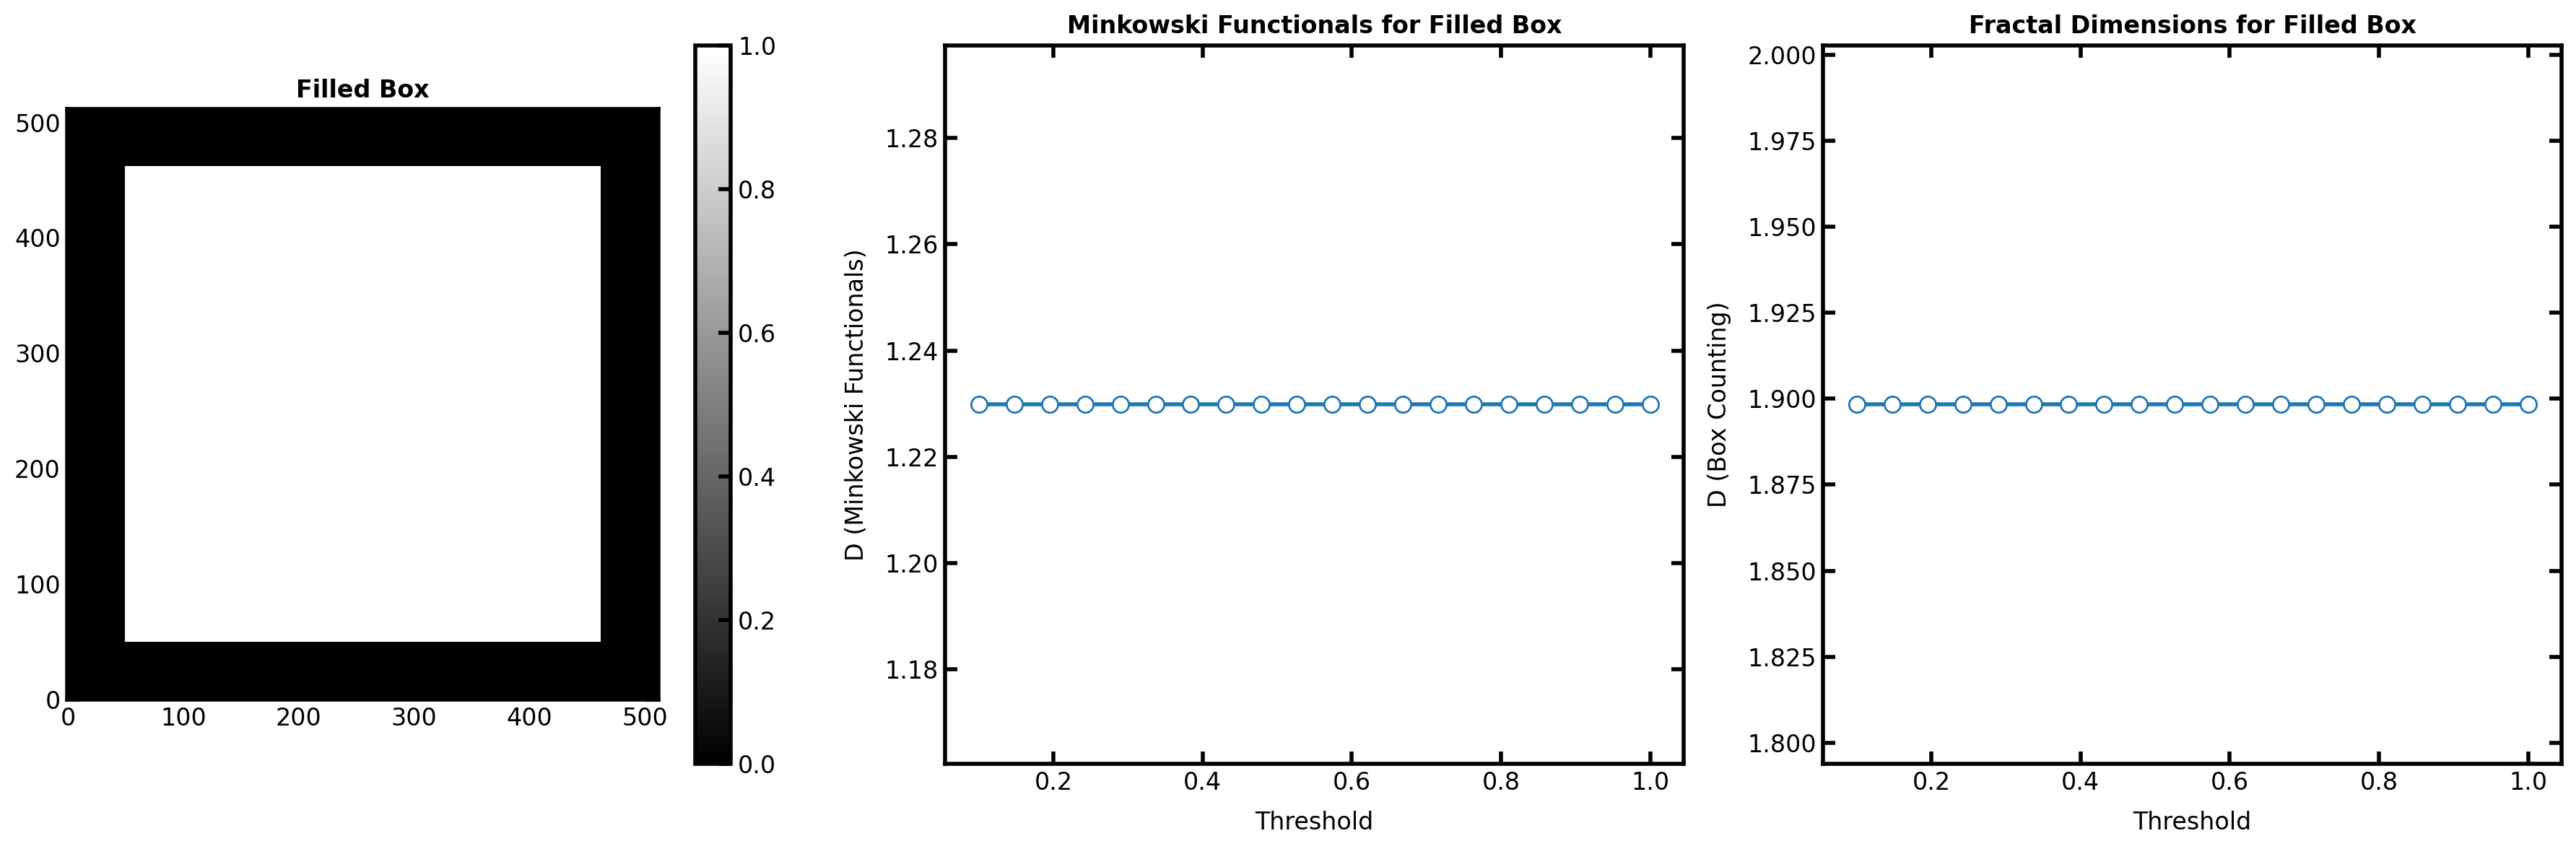

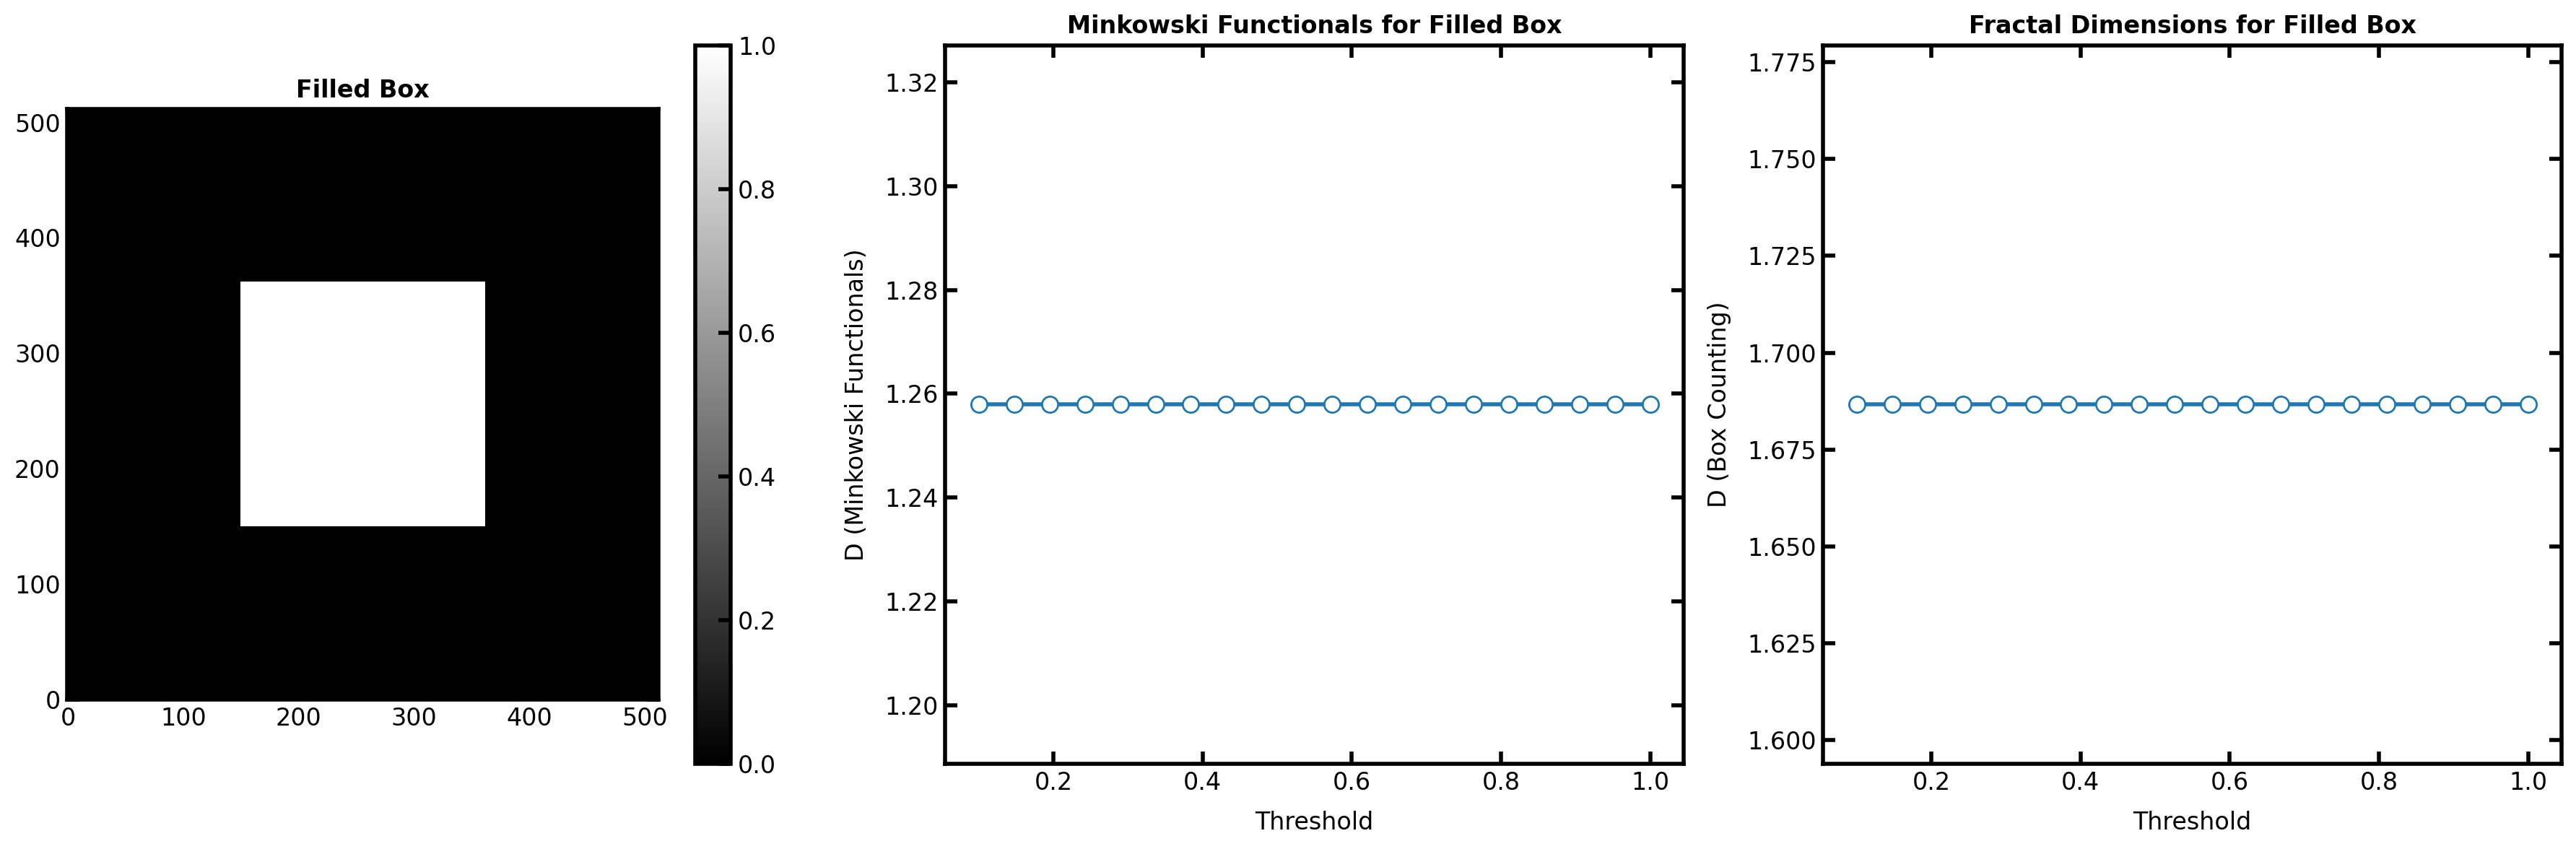

In [5]:
# PLANE WITH PADDING, k NOT ACCOUNTED
shape = (512, 512)
box_image = np.zeros(shape, dtype=bool)
padding = 50
box_image[padding:-padding, padding:-padding] = 1 

box_thresholds = np.linspace(0.1, 1, 20)
box_results = standard_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box", box_thresholds, box_results, box_fractal_dimension_BC)

box_image = np.zeros(shape, dtype=bool)
padding = 150
box_image[padding:-padding, padding:-padding] = 1

box_thresholds = np.linspace(0.1, 1, 20)
box_results = standard_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box", box_thresholds, box_results, box_fractal_dimension_BC)

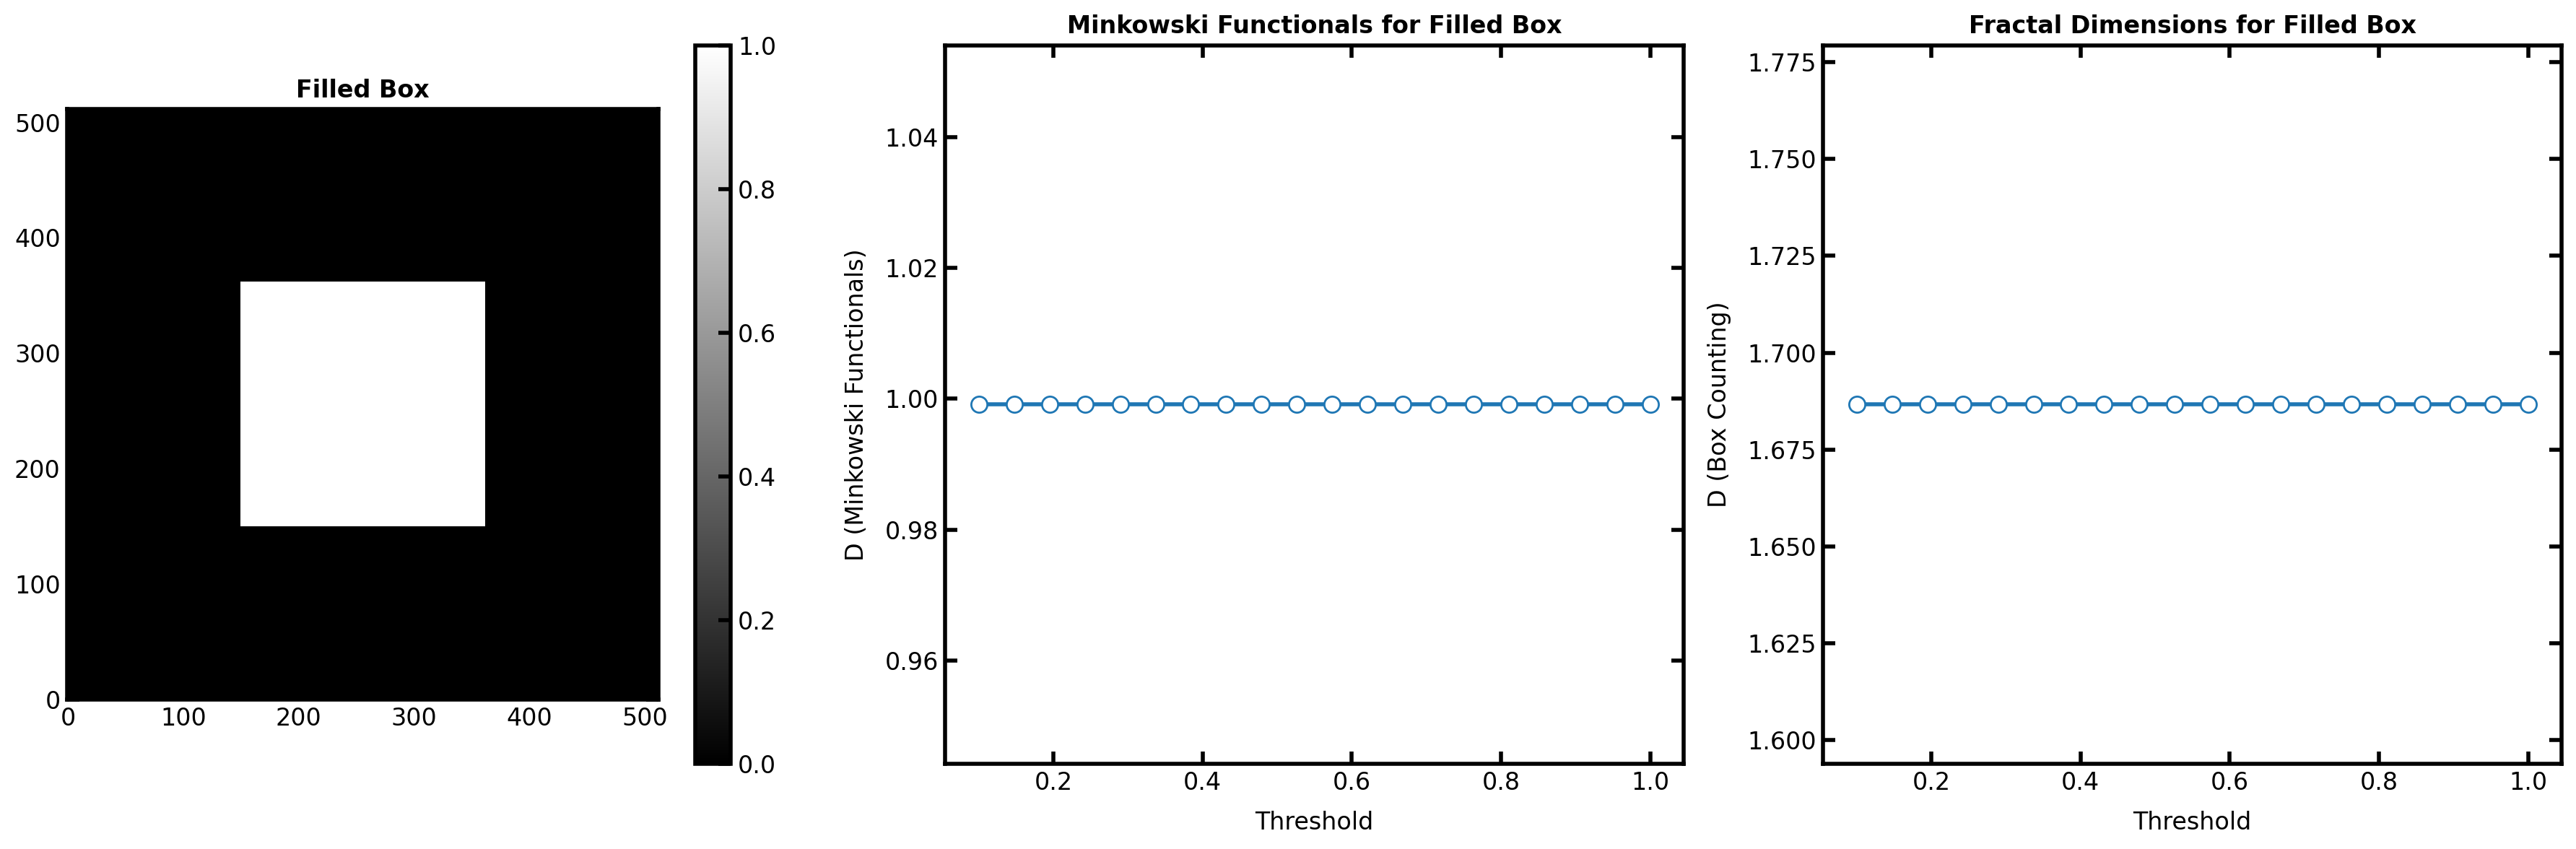

In [6]:
# PLANE WITH PADDING, k ACCOUNTED
def plane_corrected_minkowski_functionals(data, threshold_min = 1e20, threshold_max=1e22, thresholds = None):

    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    # Store Minkowski Functional values
    areas = []
    perimeters = []
    euler_chars = []

    # Process each threshold
    for threshold in thresholds:
        # Create binary mask
        mask = data >= threshold

        # Compute Area (v0)
        area = np.sum(mask)
        areas.append(area)

        # Compute Perimeter (v1) with correction for the plane dimension
        perim = perimeter(mask)/4
        perimeters.append(perim)

        # Compute Euler Characteristic (v2)
        euler_char = euler_number(mask)
        euler_chars.append(euler_char)

    # Convert to log scale for fractal dimension analysis
    log_areas = np.log10(areas)
    log_perimeters = np.log10(perimeters)

    D = 2*log_perimeters/log_areas

    return {
        "thresholds": thresholds,
        "areas": areas,
        "perimeters": perimeters,
        "euler_chars": euler_chars,
        "fractal_dimension": D
    }

# Calculate Minkowski functionals (corrected) for the box image
box_thresholds = np.linspace(0.1, 1, 20)
box_results = plane_corrected_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box", box_thresholds, box_results, box_fractal_dimension_BC)

### **Orientation**

As above, the orientation should not matter. We see that the corrected PA method remains unaffected, while the BC method still is affected. 

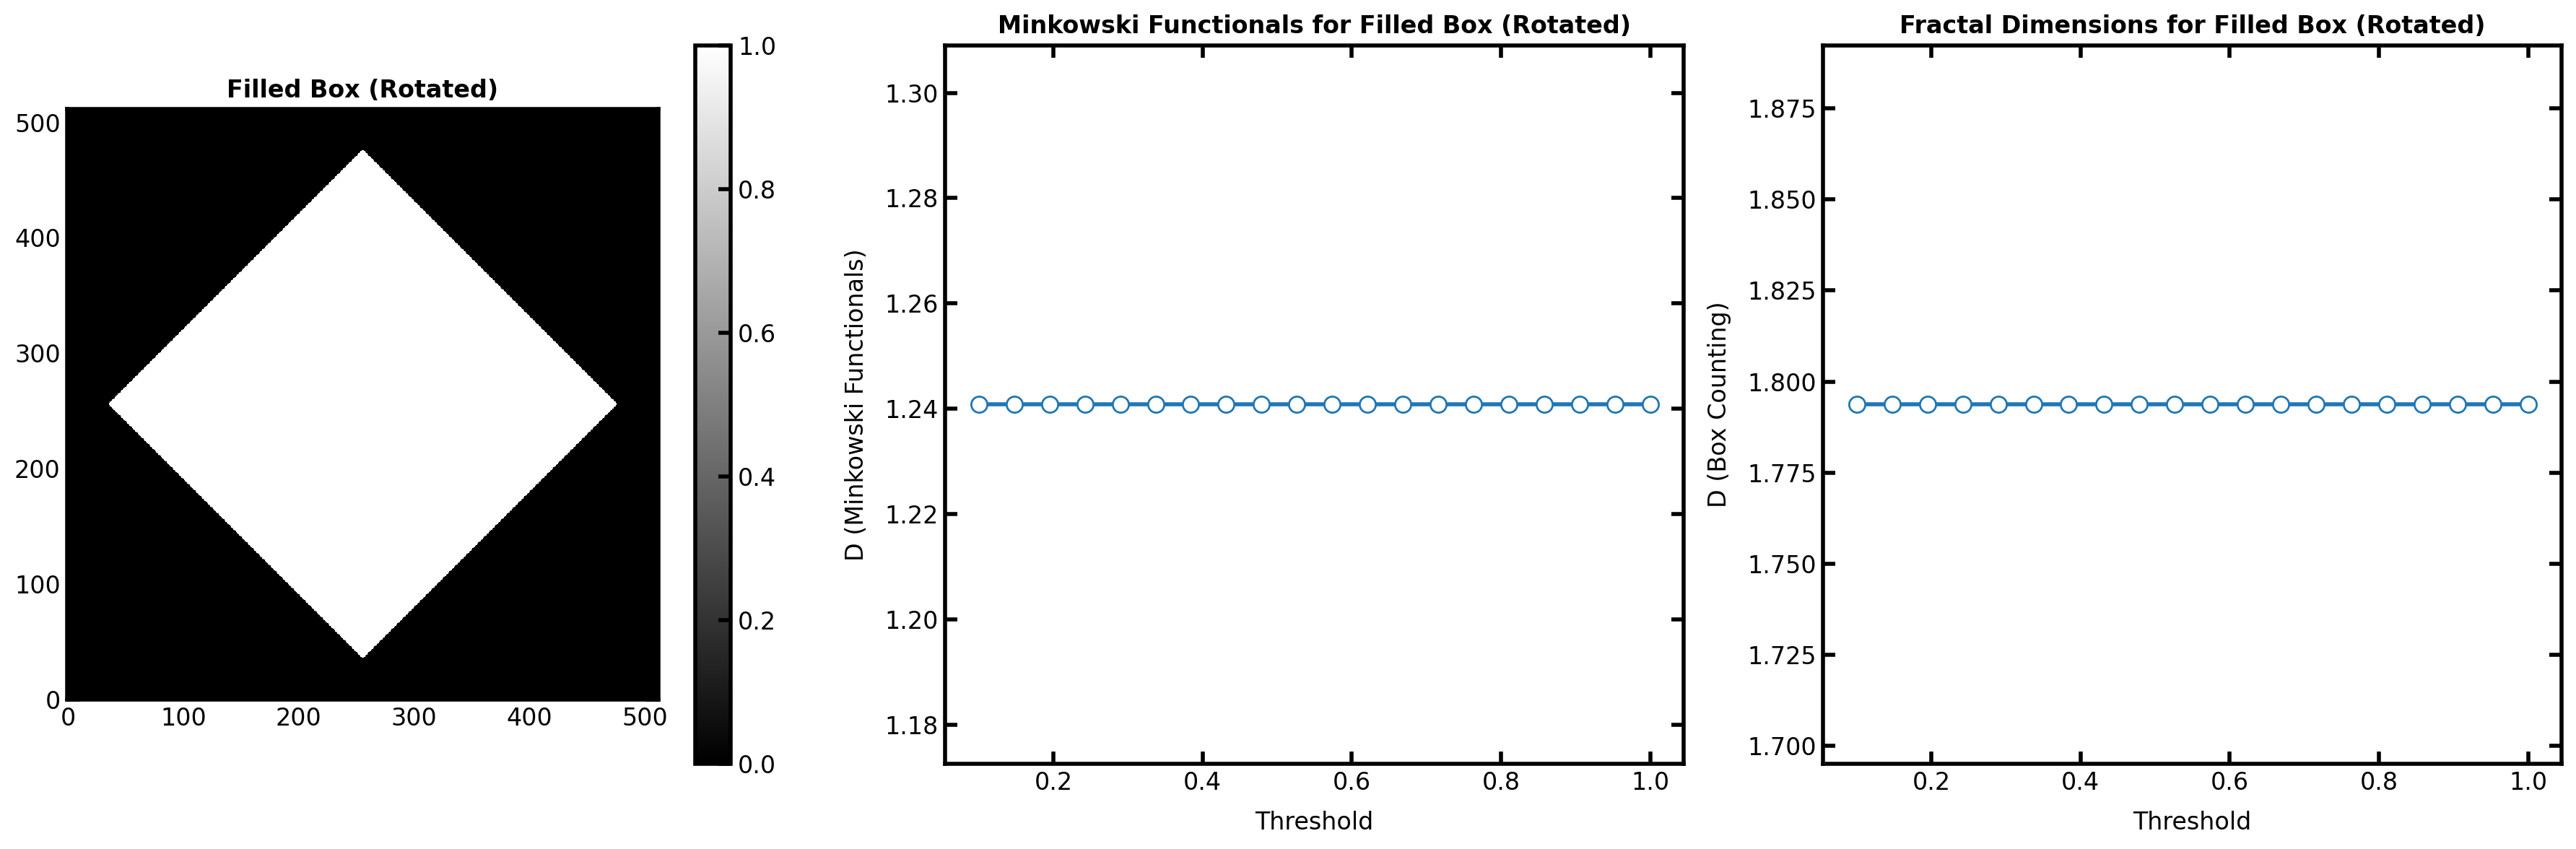

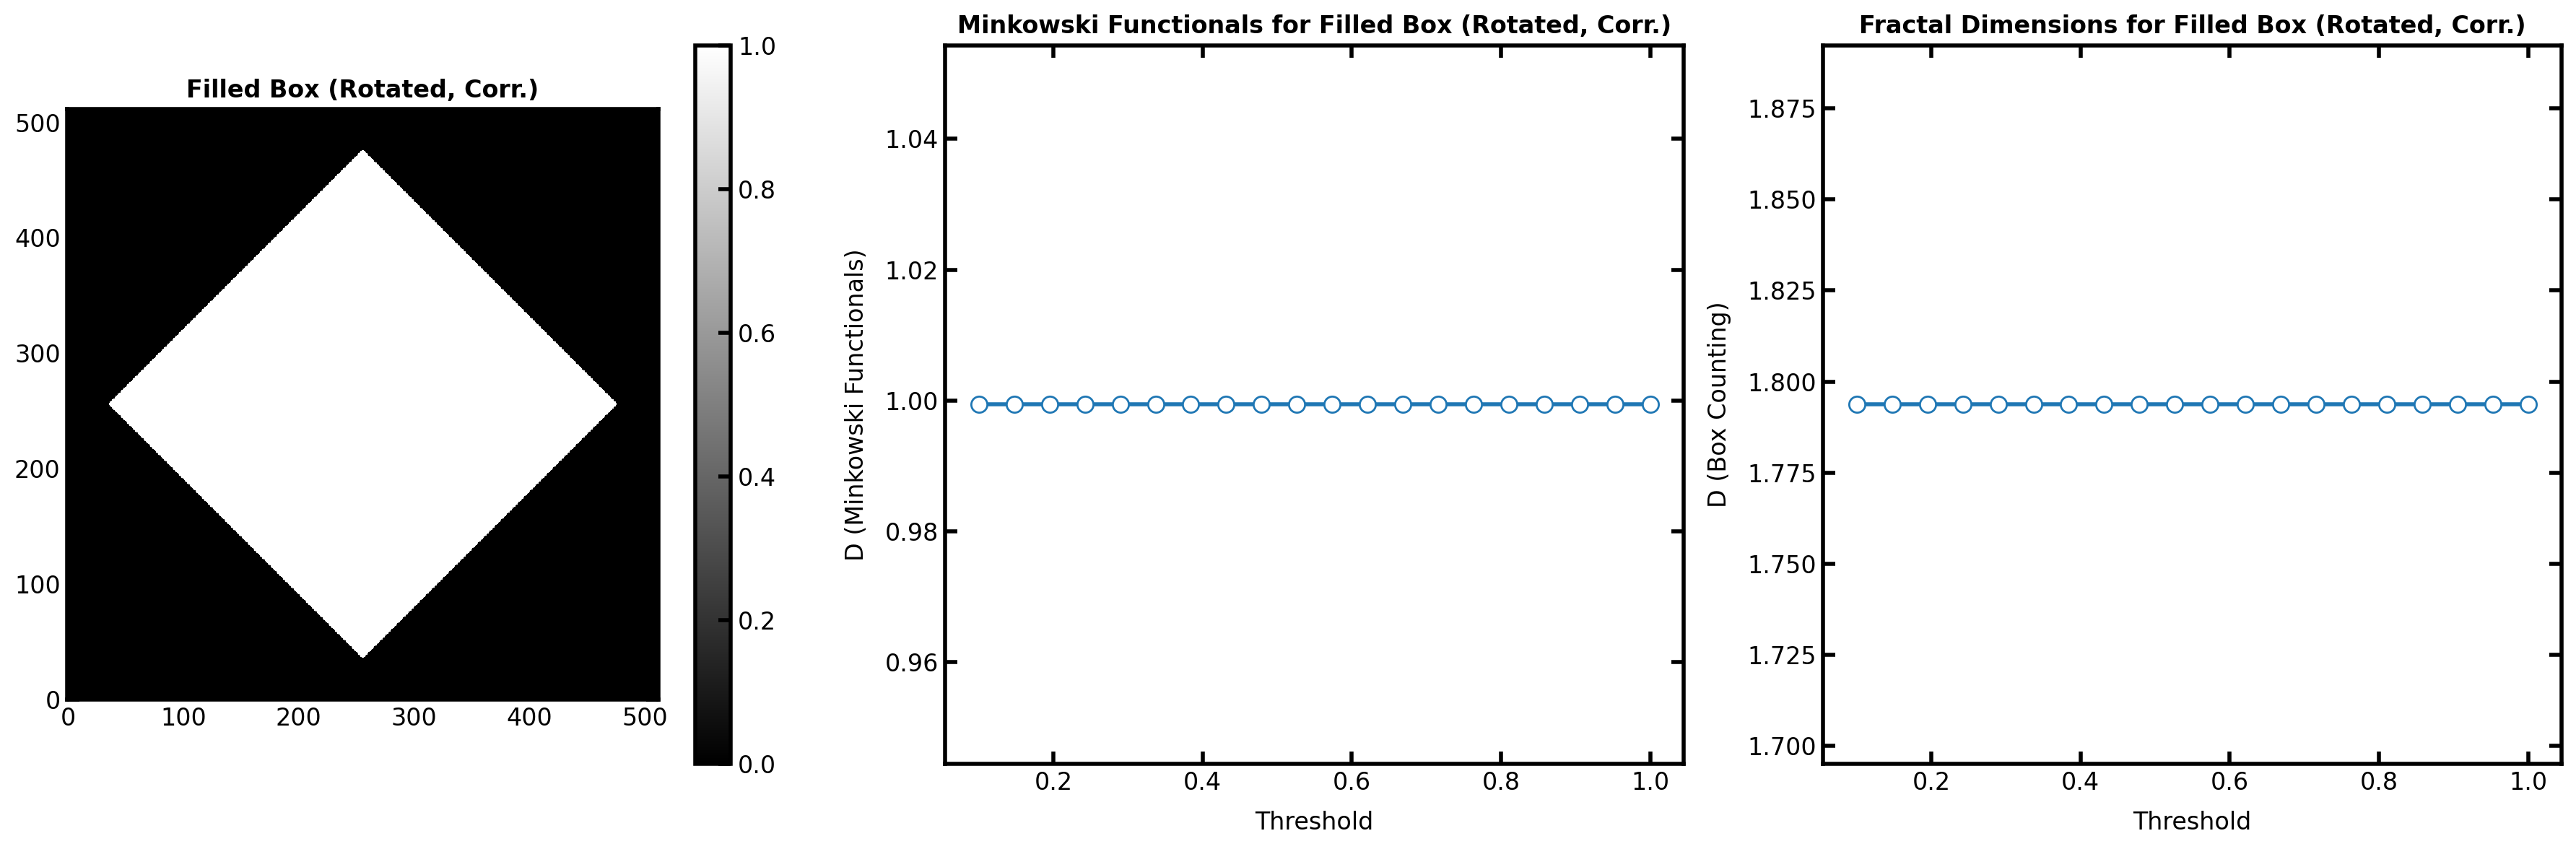

In [7]:
# PLANE WITH PADDING, k ACCOUNTED, ROTATED
shape = (512, 512)
box_image = np.zeros(shape, dtype=bool)
padding = 100  # Padding from the sides
box_image[padding:-padding, padding:-padding] = 1

box_image = rotate(box_image, angle=45, reshape=False, order=0)

box_thresholds = np.linspace(0.1, 1, 20)
box_results = standard_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box (Rotated)", box_thresholds, box_results, box_fractal_dimension_BC)

box_thresholds = np.linspace(0.1, 1, 20)
box_results = plane_corrected_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box (Rotated, Corr.)", box_thresholds, box_results, box_fractal_dimension_BC)

## **Boxes within Boxes**
---

Also following a discussion from a Group Meeting, it was asked what would happen if there was a hole/box within a bigger box. The border complexity should slightly increase. This is also a good opportunity to try to fit for the proportionality constant.

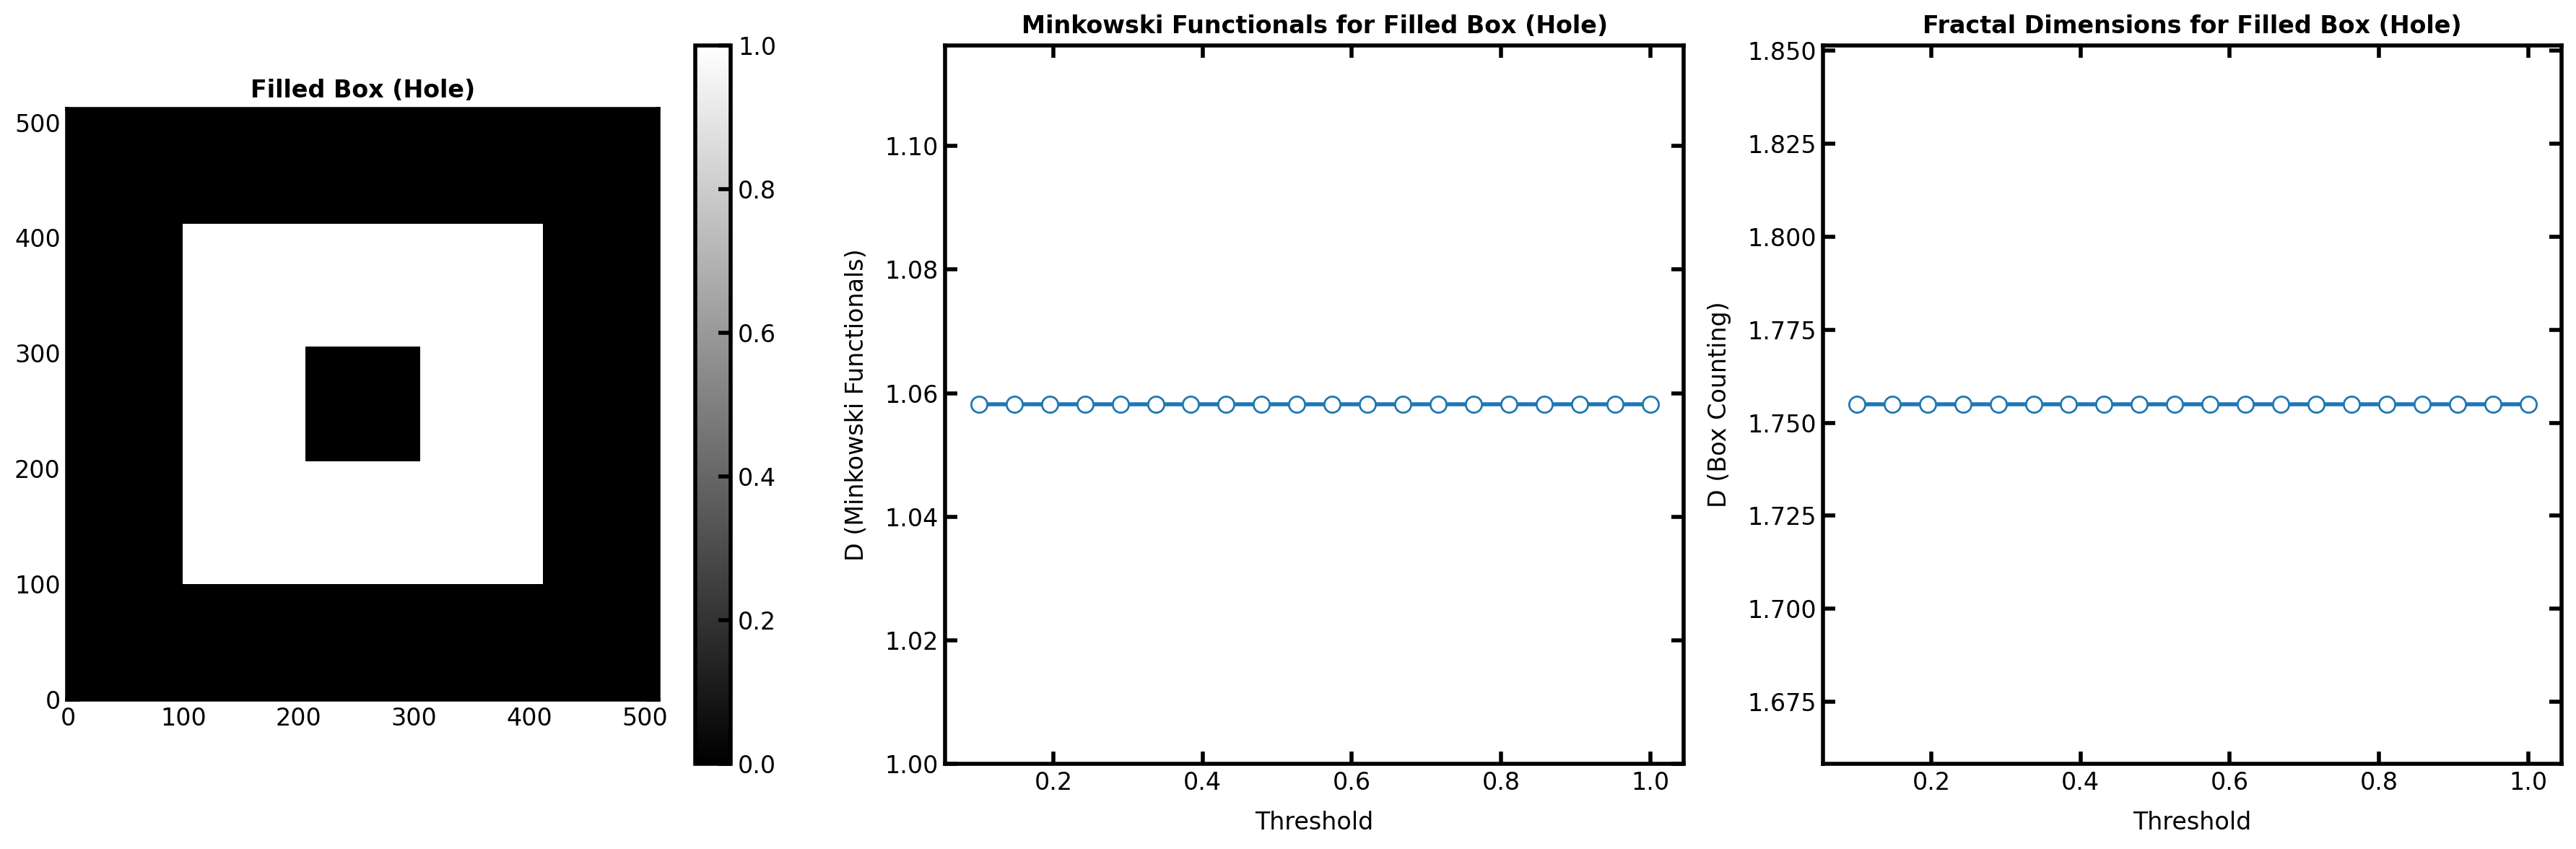

In [8]:
### PLANE WITH PADDING, k ACCOUNTED, MORE COMPLEX BORDER
shape = (512, 512)
box_image = np.zeros(shape, dtype=bool)
padding = 100 
box_image[padding:-padding, padding:-padding] = 1 

# Create a hole in the center
hole_padding = 50
box_image[shape[0] // 2 - hole_padding:shape[0] // 2 + hole_padding,
          shape[1] // 2 - hole_padding:shape[1] // 2 + hole_padding] = 0  # Box-shaped hole

box_thresholds = np.linspace(0.1, 1, 20)
box_results = plane_corrected_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box (Hole)", box_thresholds, box_results, box_fractal_dimension_BC)

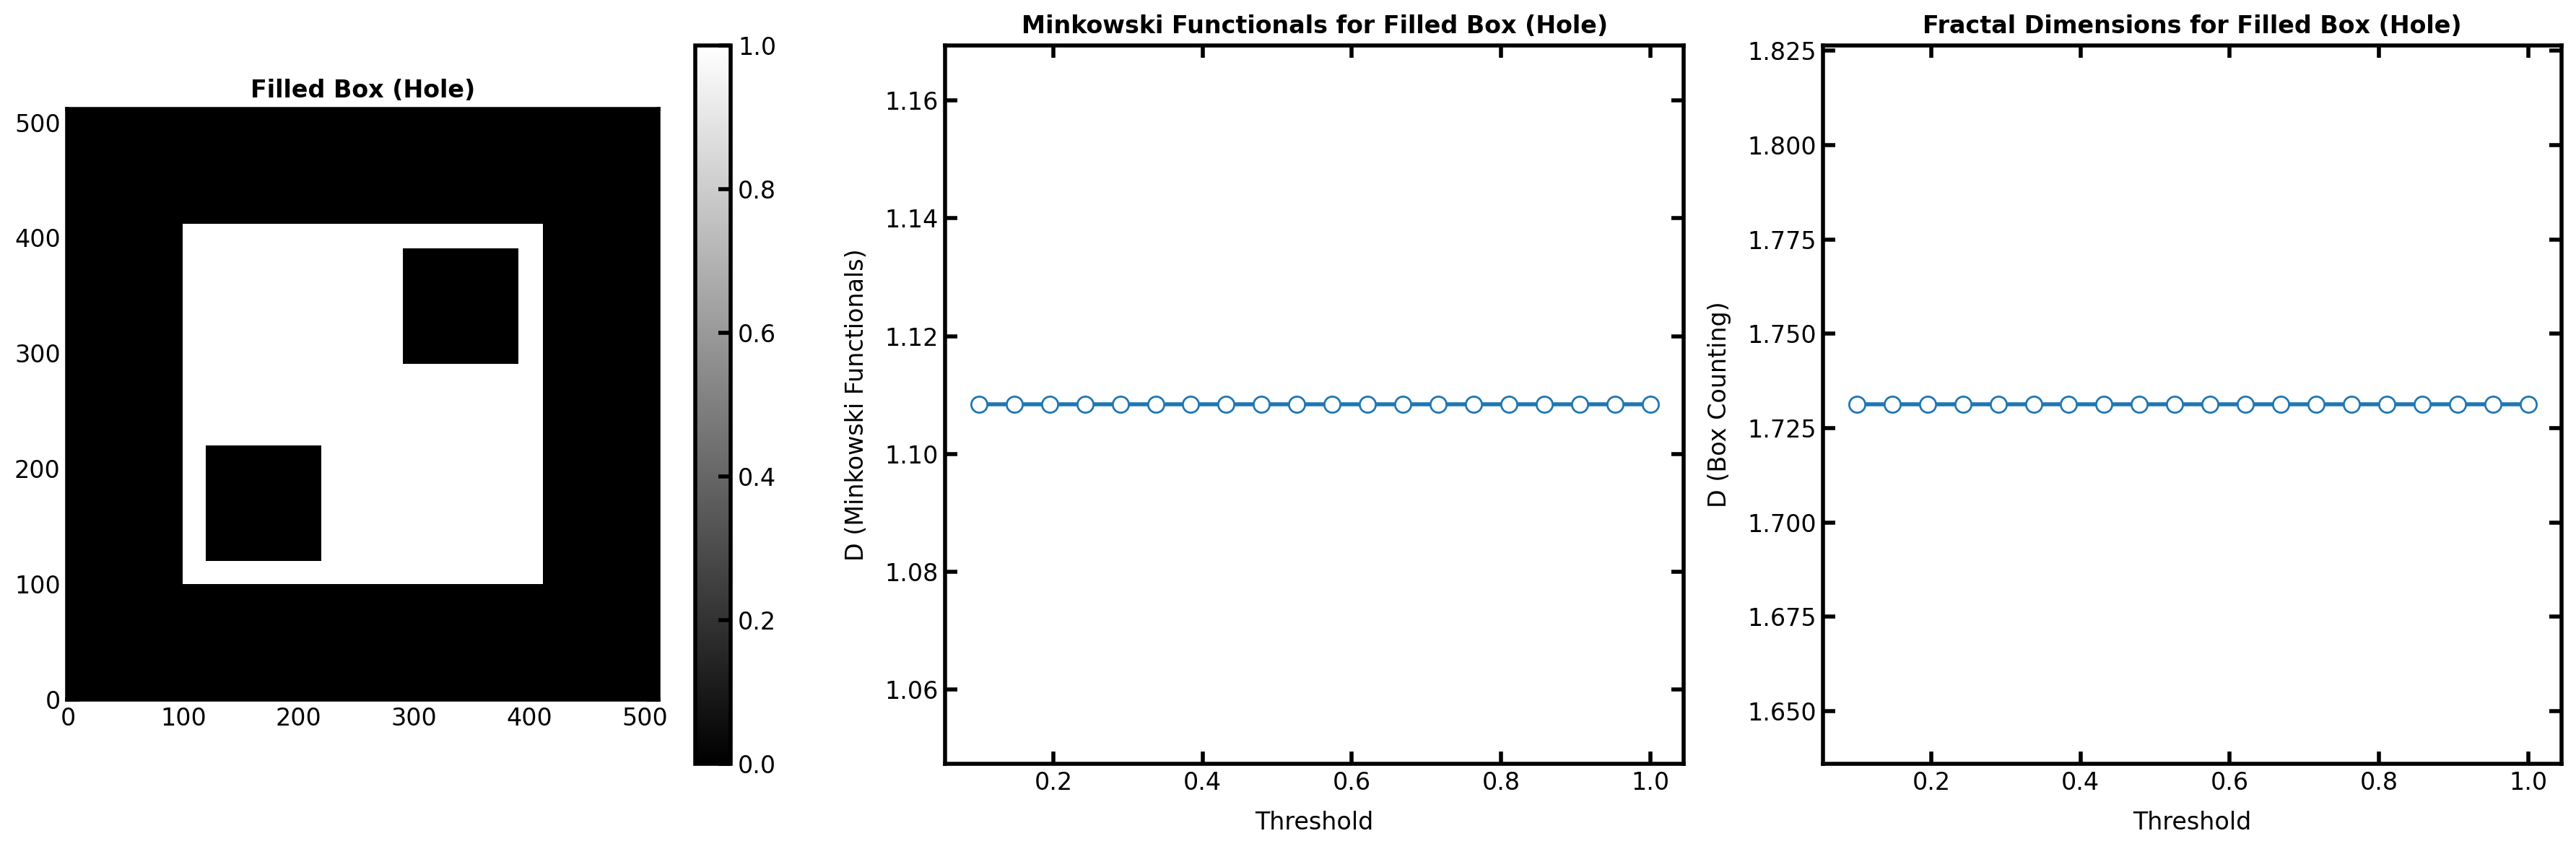

In [9]:
### PLANE WITH PADDING, k ACCOUNTED, MORE COMPLEX BORDER

shape = (512, 512)
box_image = np.zeros(shape, dtype=bool)
padding = 100 
box_image[padding:-padding, padding:-padding] = 1 

# Create two holes in the center
hole_padding = 50  
# First hole
box_image[shape[0] // 3 - hole_padding:shape[0] // 3 + hole_padding,
          shape[1] // 3 - hole_padding:shape[1] // 3 + hole_padding] = 0 
# Second hole
box_image[2 * shape[0] // 3 - hole_padding:2 * shape[0] // 3 + hole_padding,
          2 * shape[1] // 3 - hole_padding:2 * shape[1] // 3 + hole_padding] = 0

box_thresholds = np.linspace(0.1, 1, 20)
box_results = plane_corrected_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box (Hole)", box_thresholds, box_results, box_fractal_dimension_BC)

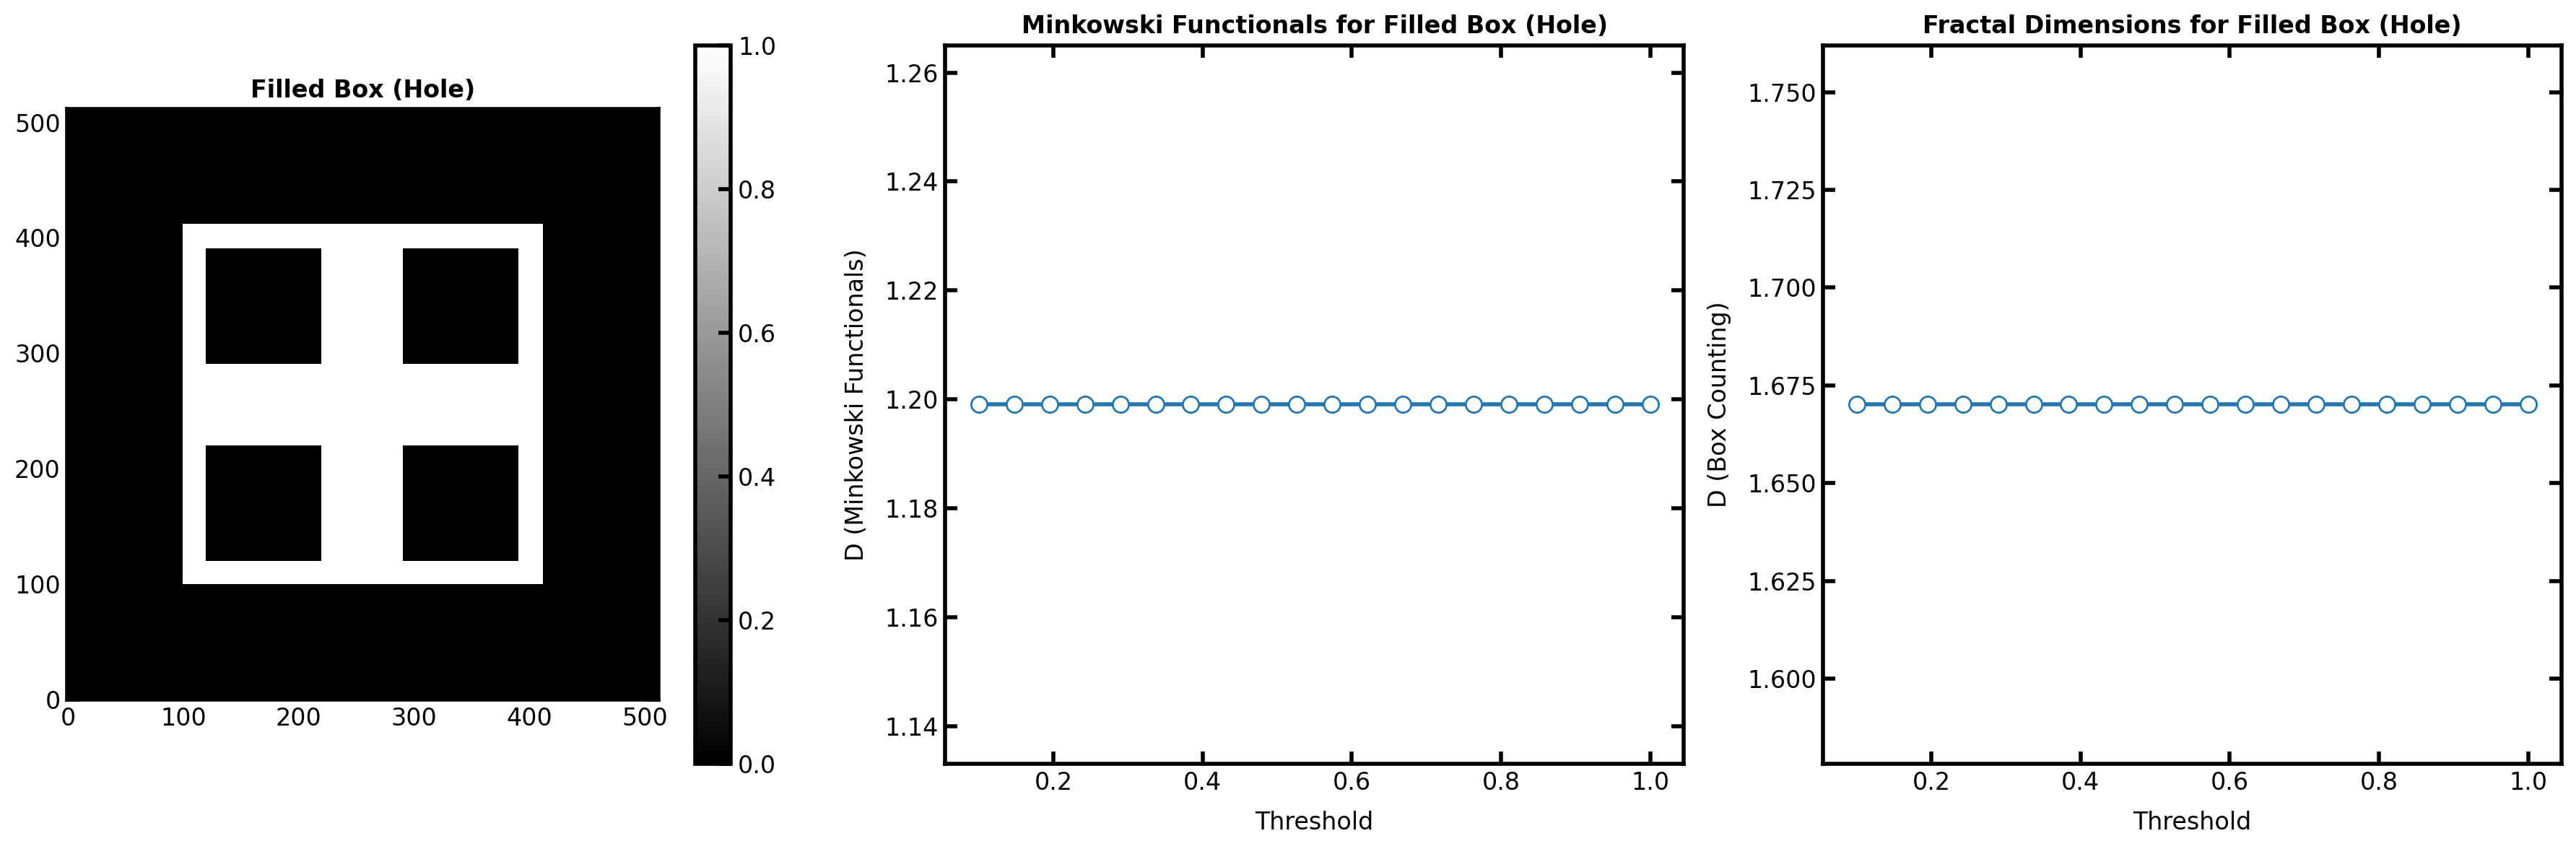

In [10]:
### PLANE WITH PADDING, k ACCOUNTED, MORE COMPLEX BORDER

shape = (512, 512)
box_image = np.zeros(shape, dtype=bool)
padding = 100 
box_image[padding:-padding, padding:-padding] = 1 

# Create four holes in the center
hole_padding = 50  # Padding for the holes
# First hole (top-left)
box_image[shape[0] // 3 - hole_padding:shape[0] // 3 + hole_padding,
          shape[1] // 3 - hole_padding:shape[1] // 3 + hole_padding] = 0  # Box-shaped hole
# Second hole (top-right)
box_image[shape[0] // 3 - hole_padding:shape[0] // 3 + hole_padding,
          2 * shape[1] // 3 - hole_padding:2 * shape[1] // 3 + hole_padding] = 0  # Box-shaped hole
# Third hole (bottom-left)
box_image[2 * shape[0] // 3 - hole_padding:2 * shape[0] // 3 + hole_padding,
          shape[1] // 3 - hole_padding:shape[1] // 3 + hole_padding] = 0  # Box-shaped hole
# Fourth hole (bottom-right)
box_image[2 * shape[0] // 3 - hole_padding:2 * shape[0] // 3 + hole_padding,
          2 * shape[1] // 3 - hole_padding:2 * shape[1] // 3 + hole_padding] = 0  # Box-shaped hole

box_thresholds = np.linspace(0.1, 1, 20)
box_results = plane_corrected_minkowski_functionals(box_image.astype(float), thresholds=box_thresholds)

box_fractal_dimension_BC = []
for threshold in box_thresholds:
    box_fractal_dimension_BC.append(box_counting(box_image >= threshold))

show_shapes_results(box_image, "Filled Box (Hole)", box_thresholds, box_results, box_fractal_dimension_BC)

### **Plane: Summary**

By applying the method on different iterations of a box we learn:
1. the *anti-correlation* continues show up in a predictable manner.
2. a correction for $k$ is necessary to obtain the proper values.
3. orientation- and scale-independent when accounted for $k$.
4. *Boxes within Boxes*: border complexity increases and that is also shown in the method with an increasing D.

## **3: A Circle**
---
The expected (fractal) dimension of a filled circle should be **D = 2** in the Box-Counting Method and **D = 1** in the Perimeter-Area (PA) relation. Reminder: this is about border complexity, and the border of a perfect circle is as complex as the one of a simple plane.

For a circle:
- **Area:** $$ A = \pi r^2 $$
- **Perimeter:** $$ P = 2 \pi r $$

From which it follows that the dimension from the PA relation should be 1. This is achieved again with the correction involving the proportionality factor.

Also important: In the Box-Counting Method, we observe a dependence on the object's scale, returning different results if the circle is smaller or bigger. The Perimeter-Area method, however, is not affected by this.

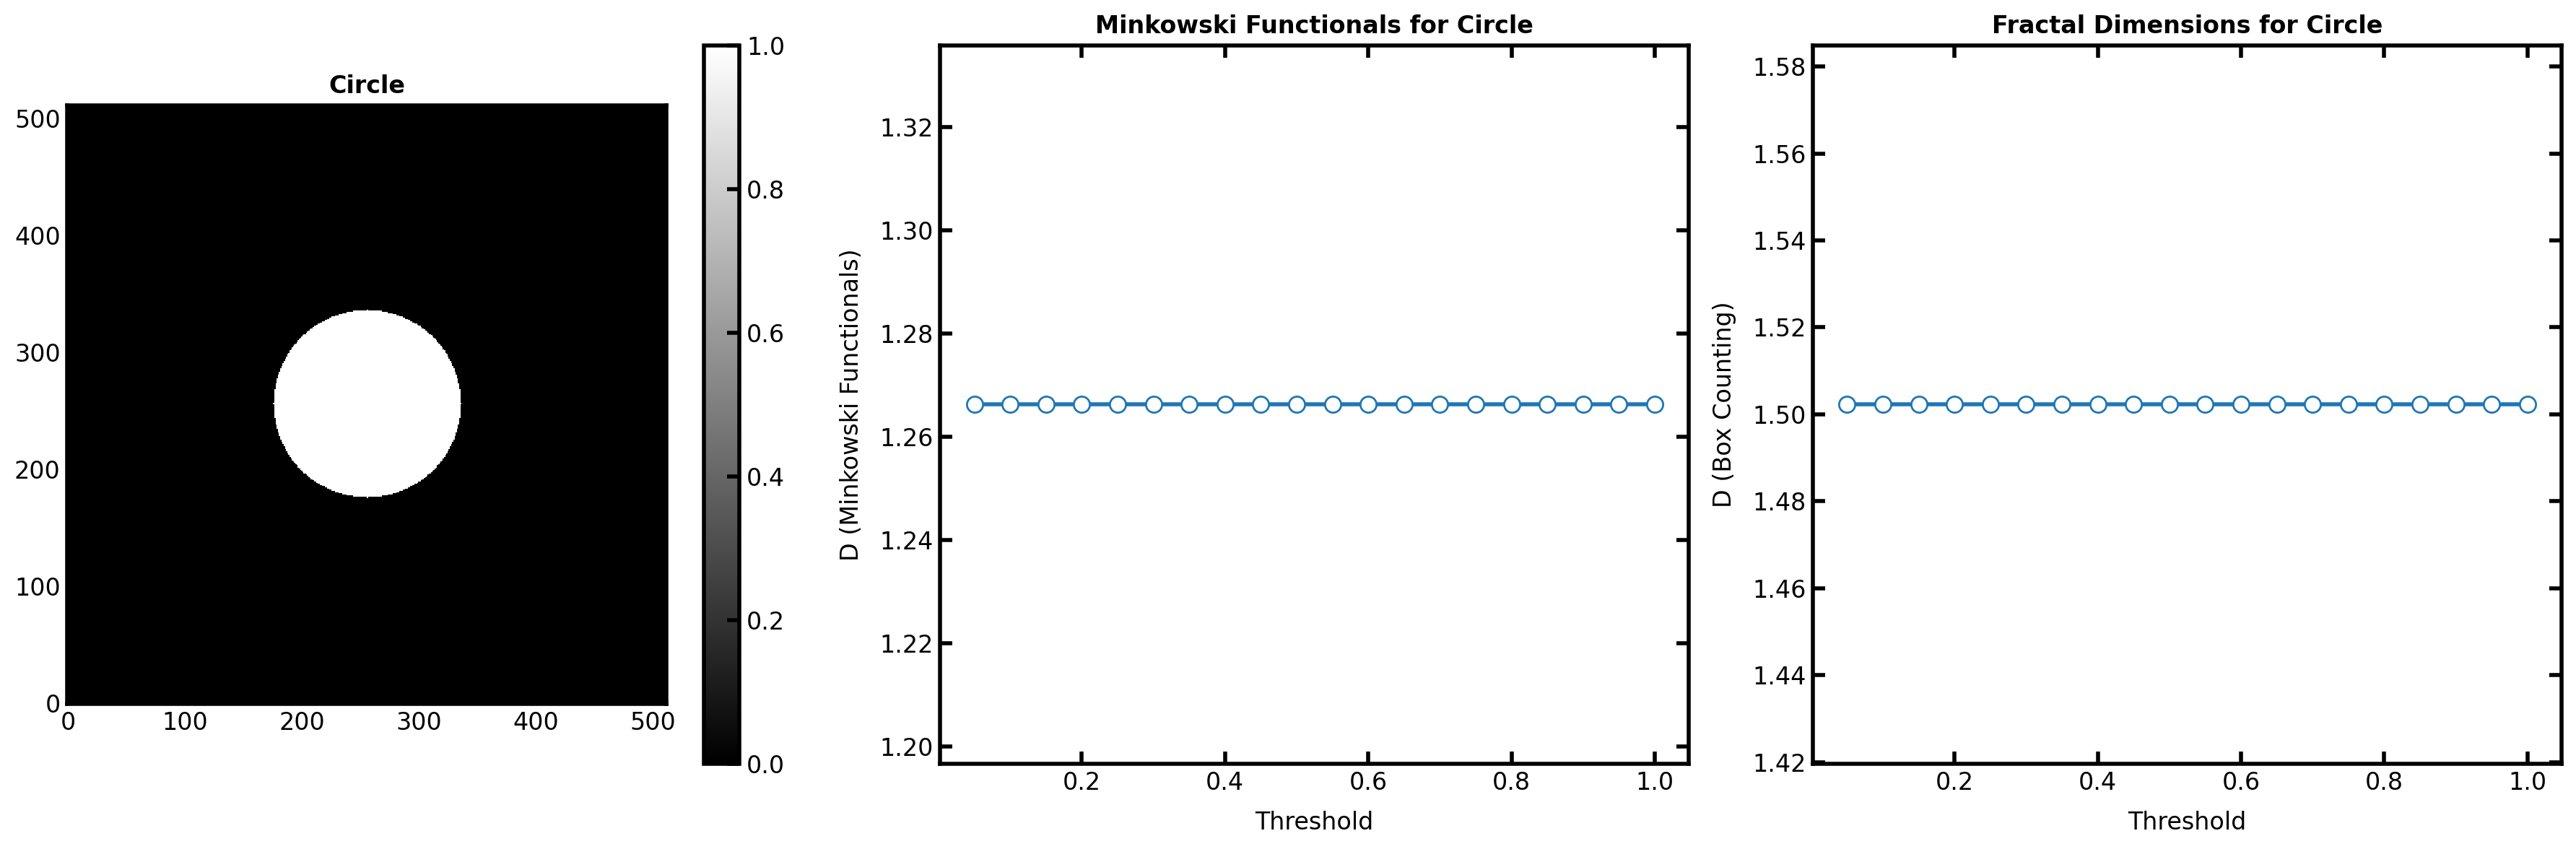

In [11]:
### CIRCLE, k NOT ACCOUNTED

circle_image = np.zeros(shape, dtype=bool)
rr, cc = np.ogrid[:shape[0], :shape[1]]
circle_center = (shape[0] // 2, shape[1] // 2)
circle_radius = 80
circle_image[(rr - circle_center[0])**2 + (cc - circle_center[1])**2 <= circle_radius**2] = 1

# Calculate Minkowski functionals for the circle image
circle_thresholds = np.linspace(0.05, 1, 20)
circle_results = standard_minkowski_functionals(circle_image.astype(float), thresholds=circle_thresholds)

# Calculate fractal dimensions using box counting method
circle_fractal_dimension_BC = []
for threshold in circle_thresholds:
    circle_fractal_dimension_BC.append(box_counting(circle_image >= threshold))

show_shapes_results(circle_image, "Circle", circle_thresholds, circle_results, circle_fractal_dimension_BC)

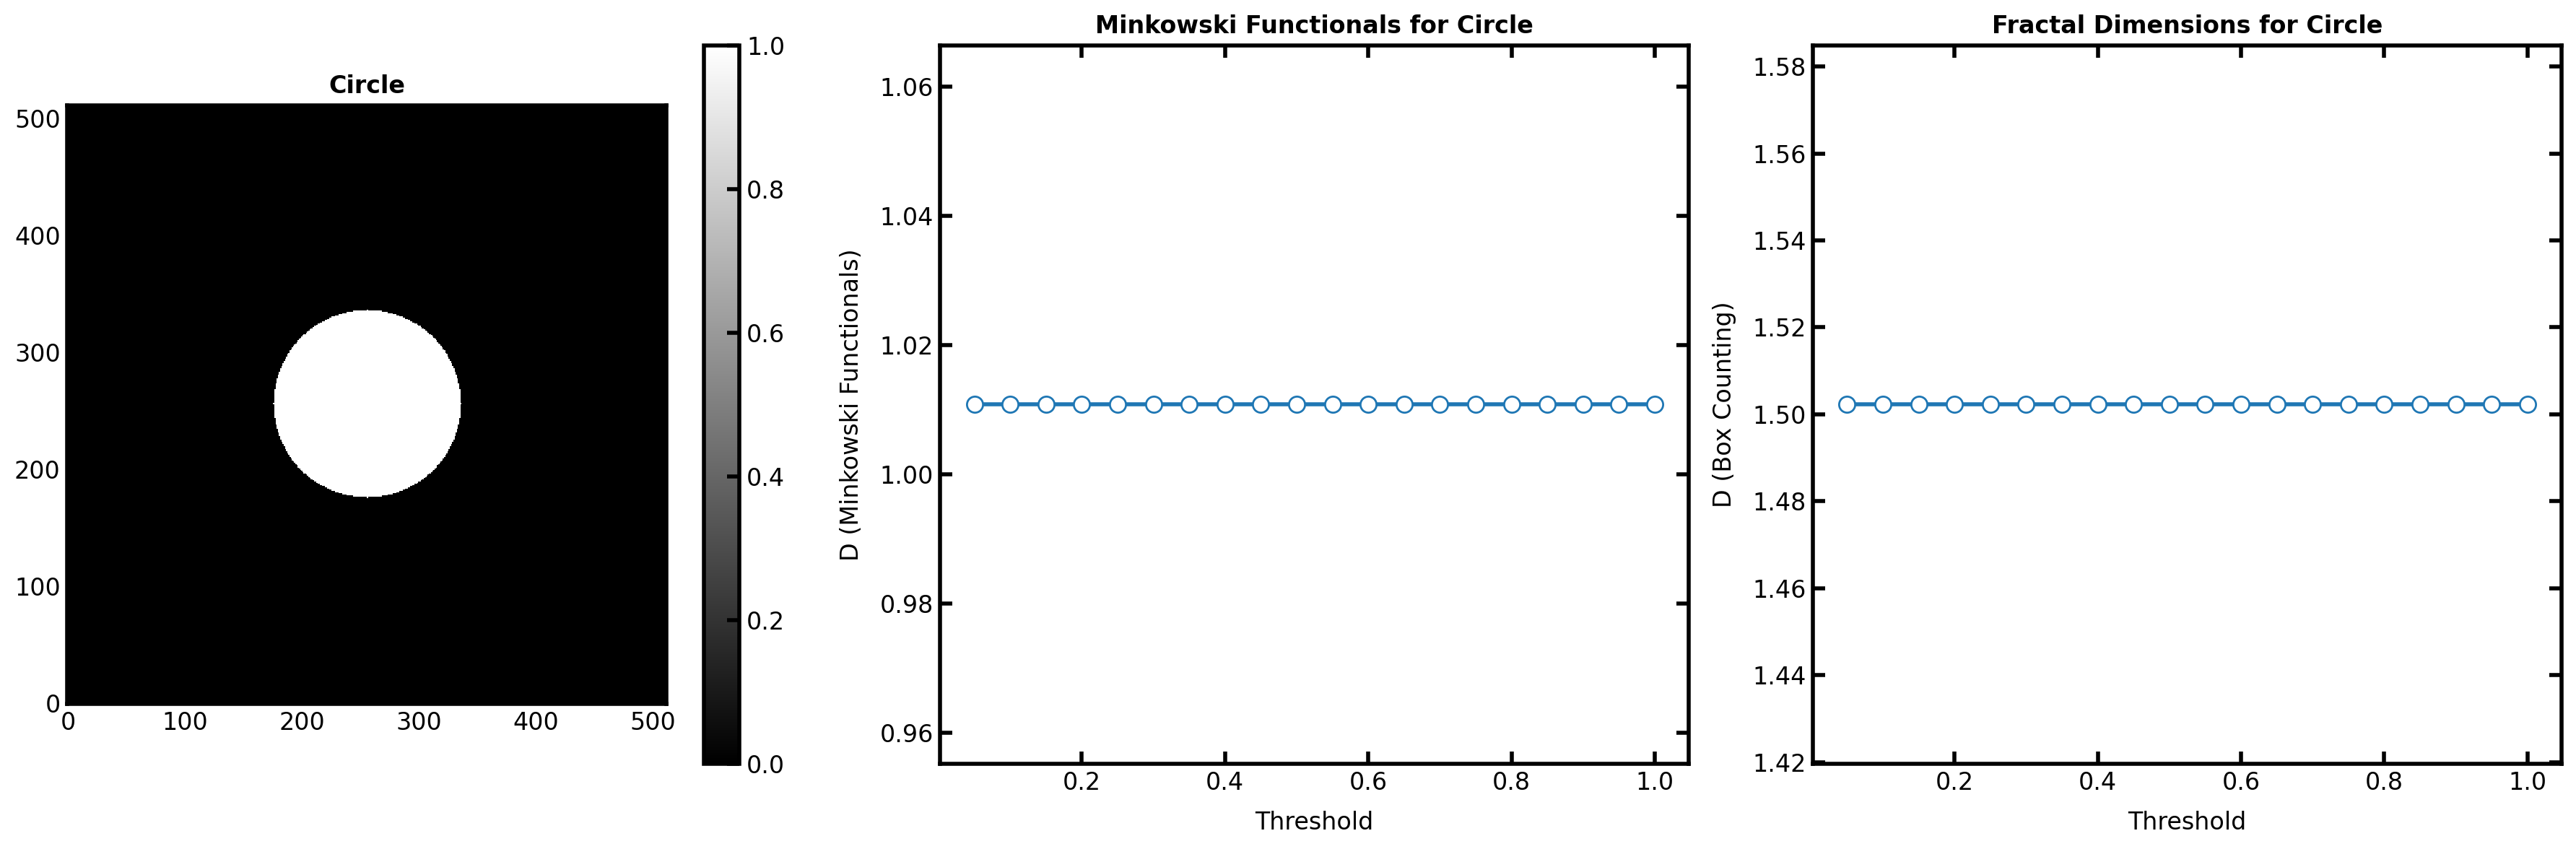

In [12]:
### CIRCLE, k ACCOUNTED

def circle_corrected_minkowski_functionals(data, threshold_min = 1e20, threshold_max=1e22, thresholds = None):

    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    # Store Minkowski Functional values
    areas = []
    perimeters = []
    euler_chars = []

    # Process each threshold
    for threshold in thresholds:
        # Create binary mask
        mask = data >= threshold

        # Compute Area (v0)
        area = np.sum(mask)
        areas.append(area)

        # Compute Perimeter (v1)
        perim = perimeter(mask)
        perimeters.append(perim)

        # Compute Euler Characteristic (v2)
        euler_char = euler_number(mask)
        euler_chars.append(euler_char)

    # Convert to log scale for fractal dimension analysis
    log_areas = np.log10(areas)
    log_perimeters = np.log10(perimeters)

    D = 2*(log_perimeters - np.log10(2*np.sqrt(np.pi)))/(log_areas)

    return {
        "thresholds": thresholds,
        "areas": areas,
        "perimeters": perimeters,
        "euler_chars": euler_chars,
        "fractal_dimension": D
    }

circle_thresholds = np.linspace(0.05, 1, 20)
circle_results = circle_corrected_minkowski_functionals(circle_image.astype(float), thresholds=circle_thresholds)

circle_fractal_dimension_BC = []
for threshold in circle_thresholds:
    circle_fractal_dimension_BC.append(box_counting(circle_image >= threshold))

show_shapes_results(circle_image, "Circle", circle_thresholds, circle_results, circle_fractal_dimension_BC)

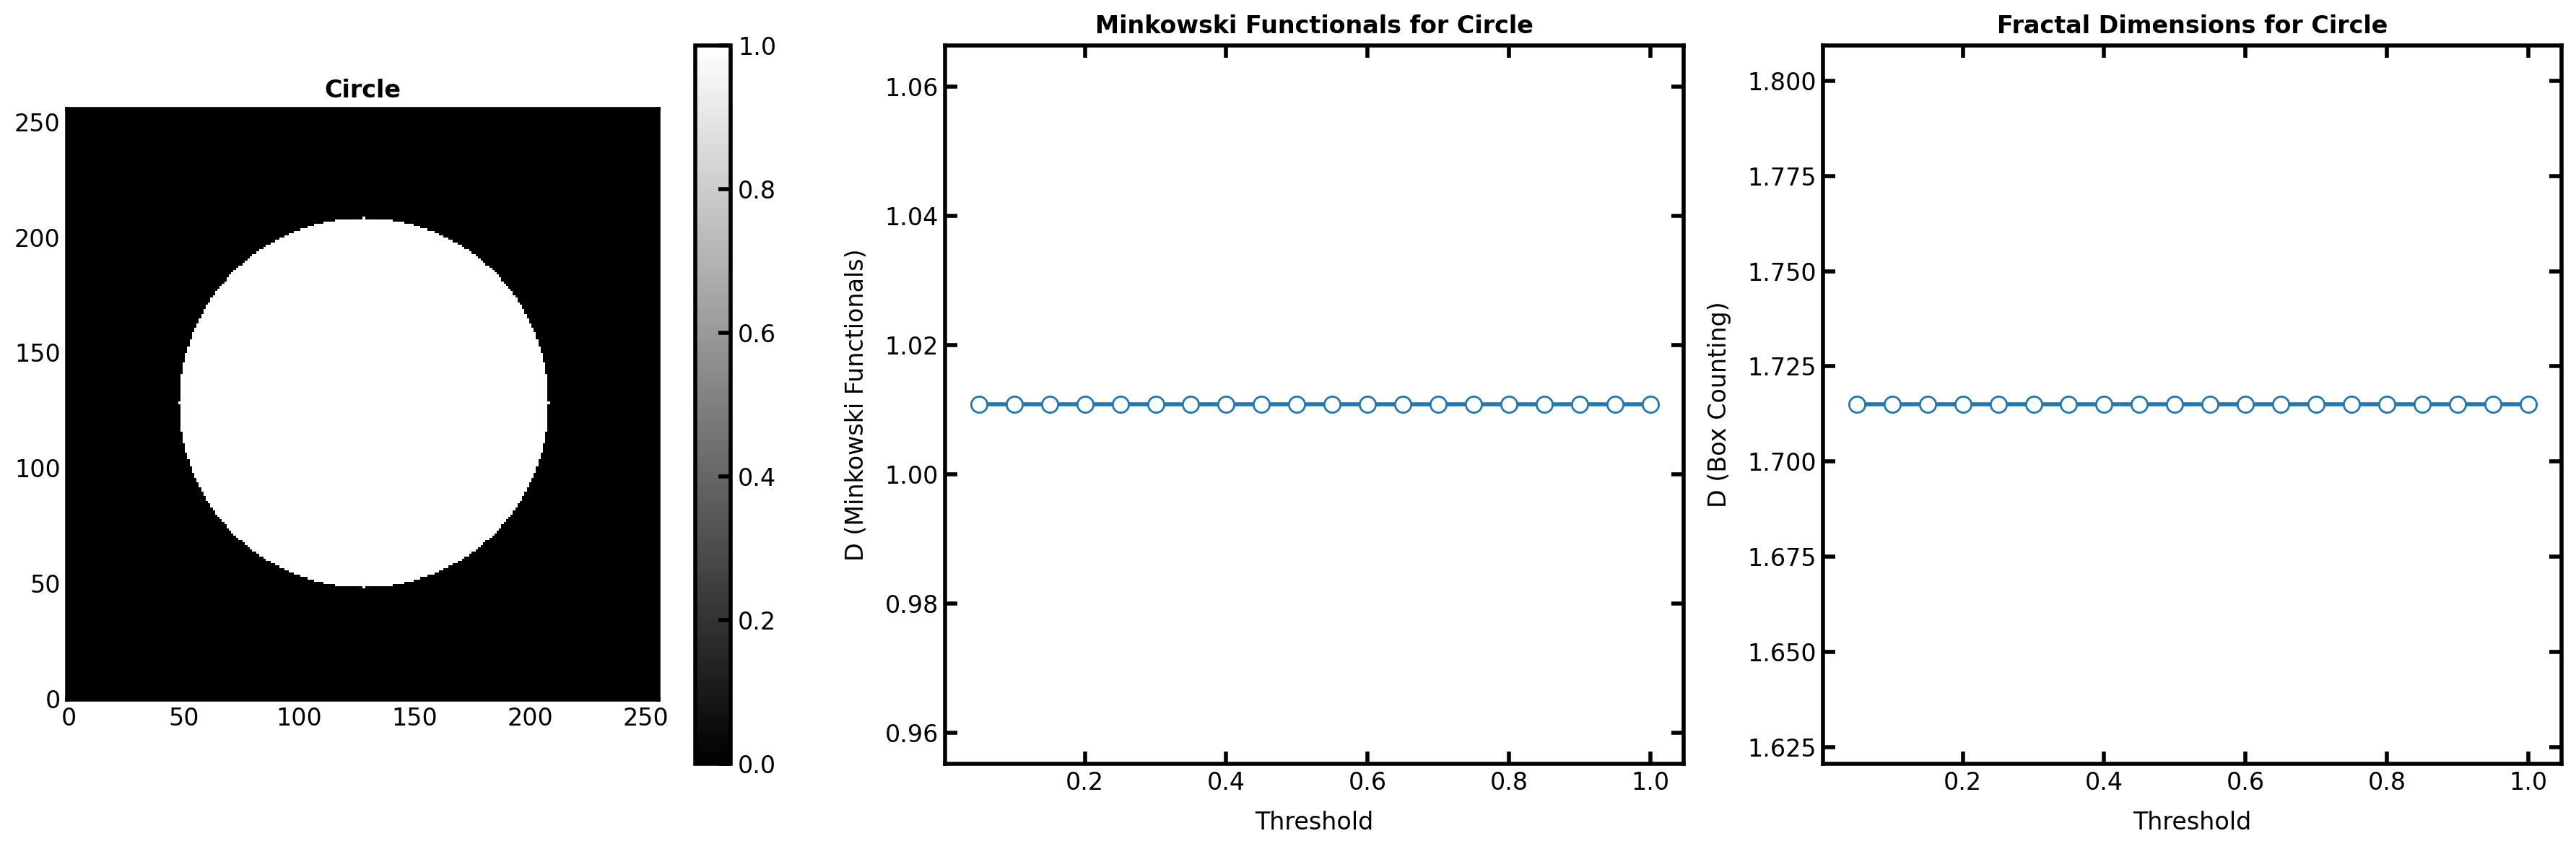

In [13]:
### CIRCLE, k ACCOUNTED, SMALLER SCALE (BC AFFECTED)

shape = (256, 256)

circle_image = np.zeros(shape, dtype=bool)
rr, cc = np.ogrid[:shape[0], :shape[1]]
circle_center = (shape[0] // 2, shape[1] // 2)
circle_radius = 80
circle_image[(rr - circle_center[0])**2 + (cc - circle_center[1])**2 <= circle_radius**2] = 1

circle_thresholds = np.linspace(0.05, 1, 20)
circle_results = circle_corrected_minkowski_functionals(circle_image.astype(float), thresholds=circle_thresholds)

circle_fractal_dimension_BC = []
for threshold in circle_thresholds:
    circle_fractal_dimension_BC.append(box_counting(circle_image >= threshold))

show_shapes_results(circle_image, "Circle", circle_thresholds, circle_results, circle_fractal_dimension_BC)

The questions of padding and orientation are not very relevant here.

## **Circle: Summary**
By appling the method to the circle we learned this:
1. anti-correlation still continues to show up in an expected manner.
2. circle has the same border complexity of a simple box.
3. really needs to account for $k$.
4. discretization errors can be quite relevant.

## **4: Fractal: The Sierpinski Triangle**
---
This is another stricking example of the anti-correlation. Even in the case of an actual fractal, the two methods behave in opposite ways. But this is no simple shape like above, and a simple correction is a bit harded to implement as the perimeter grows to infinity and the area to 0 for each iteration.

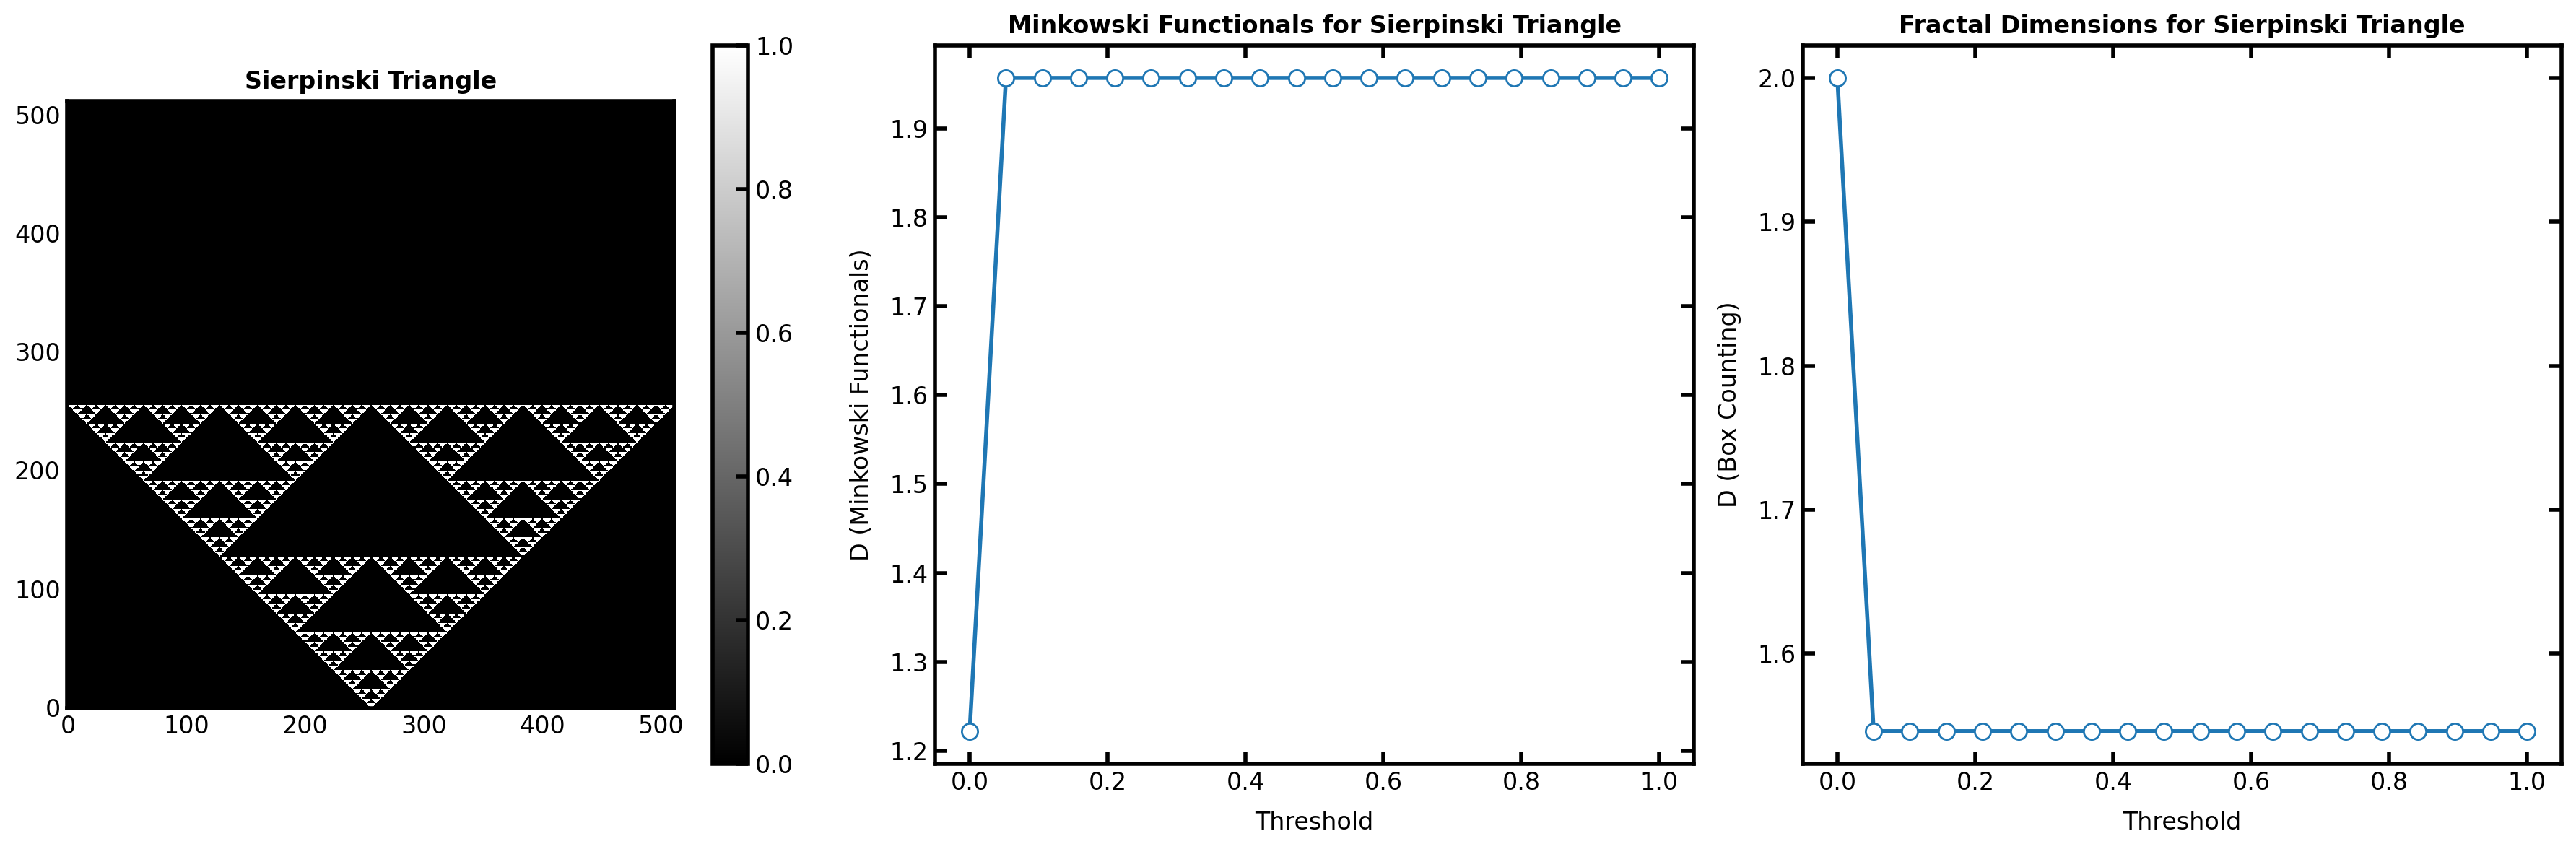

In [ ]:
### FRACTAL, k NOT ACCOUNTED

true_dimension = 1.58496
size = 512
iterations = 6
sierpinski_triangle = generate_sierpinski_triangle(size, iterations)

# Calculate Minkowski functionals for the Gaussian
sierpinski_thresholds = np.linspace(np.min(sierpinski_triangle), np.max(sierpinski_triangle), 20)
sierpinski_results = standard_minkowski_functionals(sierpinski_triangle, thresholds=sierpinski_thresholds)

# Calculate fractal dimensions using box counting method
sierpinski_thresholds_fractal_dimensions_BC = []
for threshold in sierpinski_thresholds:
    sierpinski_thresholds_fractal_dimensions_BC.append(box_counting(sierpinski_triangle >= threshold))

show_shapes_results(sierpinski_triangle, "Sierpinski Triangle", sierpinski_thresholds, sierpinski_results, sierpinski_thresholds_fractal_dimensions_BC)

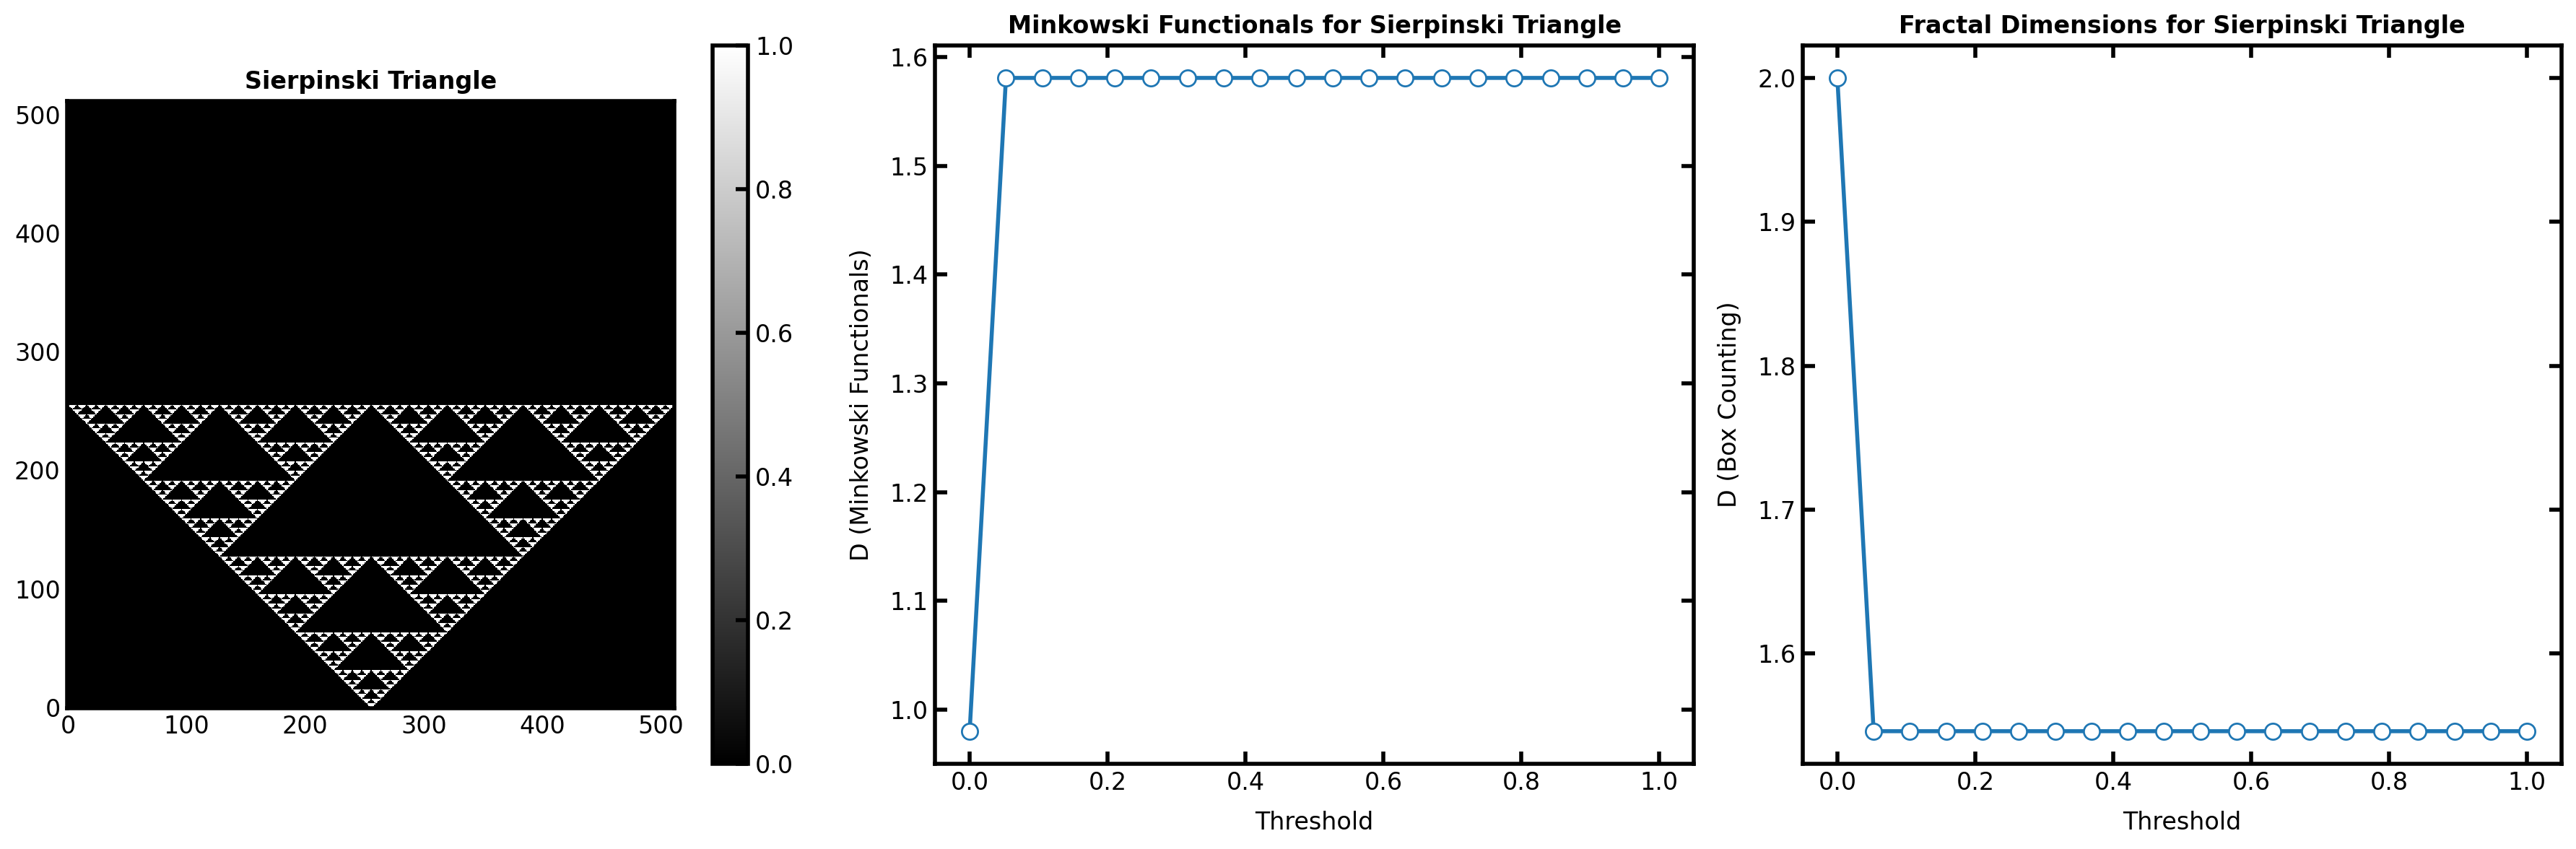

In [ ]:
### FRACTAL, k ACCOUNTED
def sierpinski_corrected_minkowski_functionals(data, threshold_min = 1e20, threshold_max=1e22, thresholds = None):

    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    # Store Minkowski Functional values
    areas = []
    perimeters = []
    euler_chars = []

    # Process each threshold
    for threshold in thresholds:
        # Create binary mask
        mask = data >= threshold

        # Compute Area (v0)
        area = np.sum(mask)
        areas.append(area)

        # Compute Perimeter (v1)
        perim = perimeter(mask)
        perimeters.append(perim)

        # Compute Euler Characteristic (v2)
        euler_char = euler_number(mask)
        euler_chars.append(euler_char)

    # Convert to log scale for fractal dimension analysis (To Do: ther should be a k-dependency for these factors)
    vorfaktor_1 = np.sqrt(3)/4
    vorfaktor_2 = 3
    
    log_areas = np.log10(1/vorfaktor_1*np.array(areas))

    log_perimeters = np.log10(1/vorfaktor_2*np.array(perimeters))


    D = 2*(log_perimeters)/(log_areas)

    return {
        "thresholds": thresholds,
        "areas": areas,
        "perimeters": perimeters,
        "euler_chars": euler_chars,
        "fractal_dimension": D
    }

true_dimension = 1.58496
size = 512
iterations = 6
sierpinski_triangle = generate_sierpinski_triangle(size, iterations)

# Calculate Minkowski functionals for the Gaussian
sierpinski_thresholds = np.linspace(np.min(sierpinski_triangle), np.max(sierpinski_triangle), 20)
sierpinski_results = sierpinski_corrected_minkowski_functionals(sierpinski_triangle, thresholds=sierpinski_thresholds)

# Calculate fractal dimensions using box counting method
sierpinski_thresholds_fractal_dimensions_BC = []
for threshold in sierpinski_thresholds:
    sierpinski_thresholds_fractal_dimensions_BC.append(box_counting(sierpinski_triangle >= threshold))

show_shapes_results(sierpinski_triangle, "Sierpinski Triangle", sierpinski_thresholds, sierpinski_results, sierpinski_thresholds_fractal_dimensions_BC)

# 📌 **Fitting for $k$**
---
With these three simple shapes we have obtained some expectation values for when we fit for $k$. In the following I fit for the proportionality constant for a few more case scenarios.

## **1: A 2D-Gaussian**
---
The 2D Gaussian should return a fractal dimension of around 1, from the results above. This is indeed the case when the proportionality factor is accounted for.

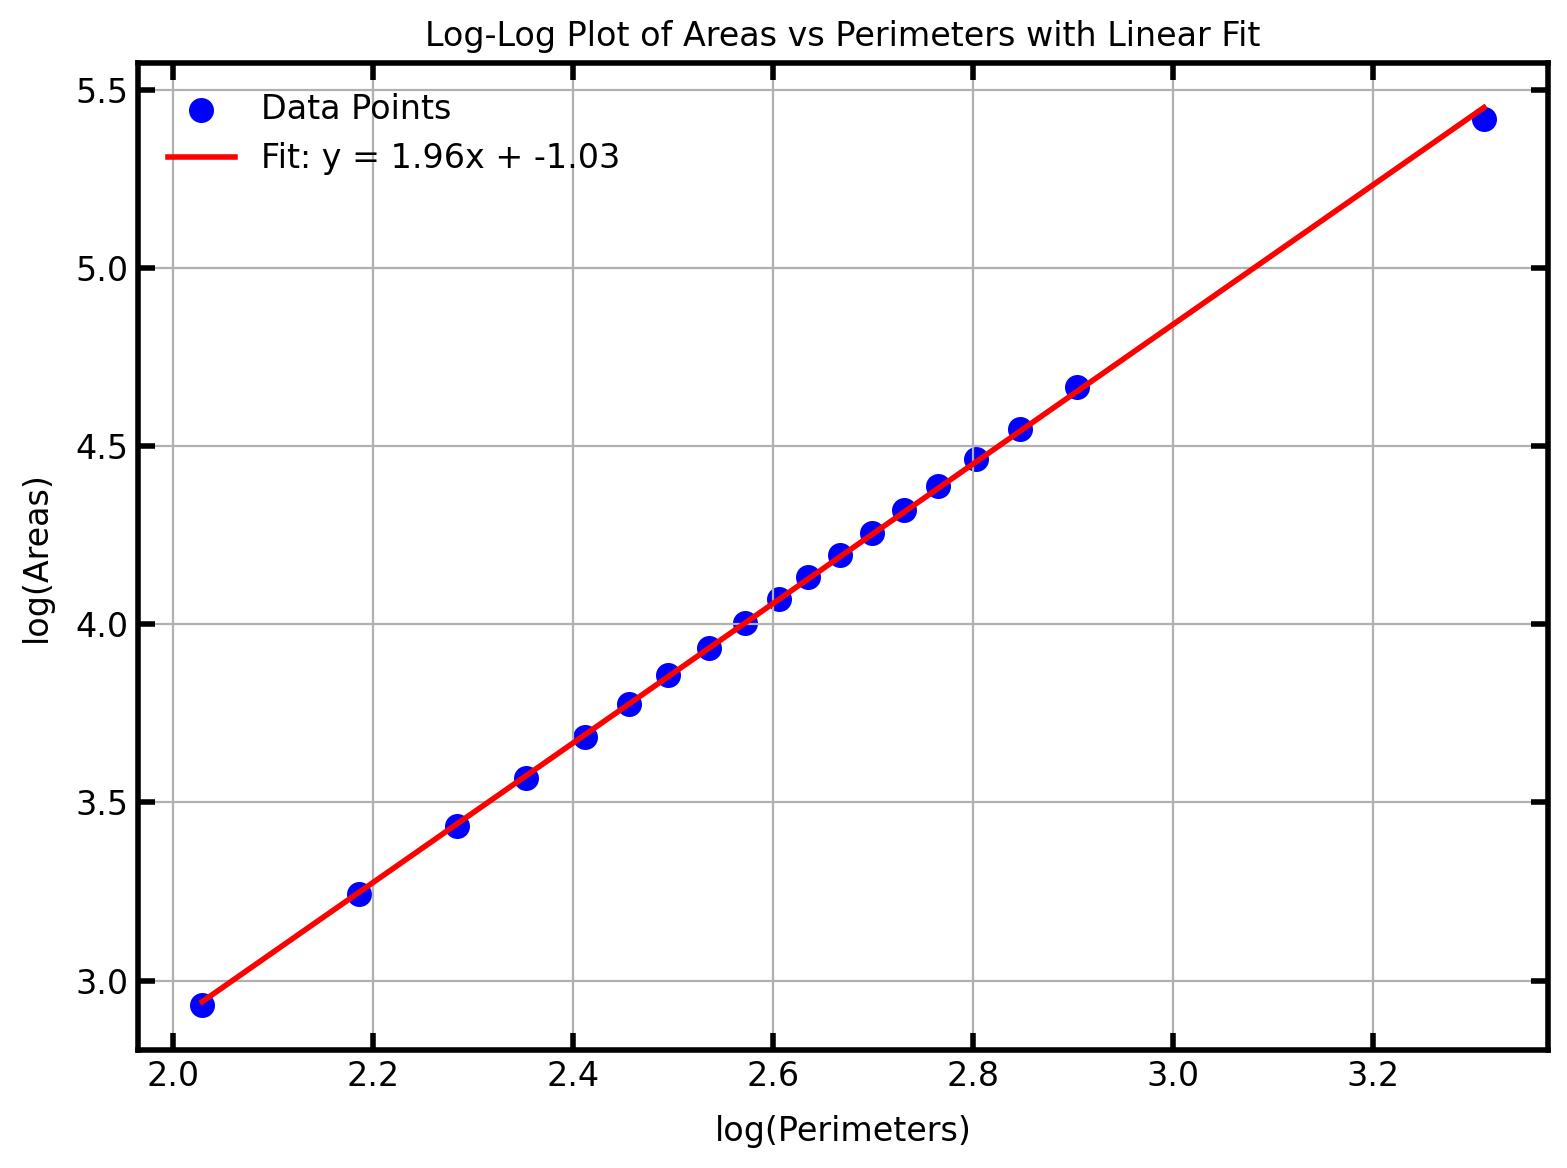

[1.02641463 1.0193982  1.02022441 1.02011487 1.02012099 1.02012623
 1.02030005 1.02024711 1.02027012 1.02158369 1.02129332 1.02129235
 1.02054144 1.02161673 1.02323134 1.02241247 1.02296029 1.02283506
 1.02398925       -inf]


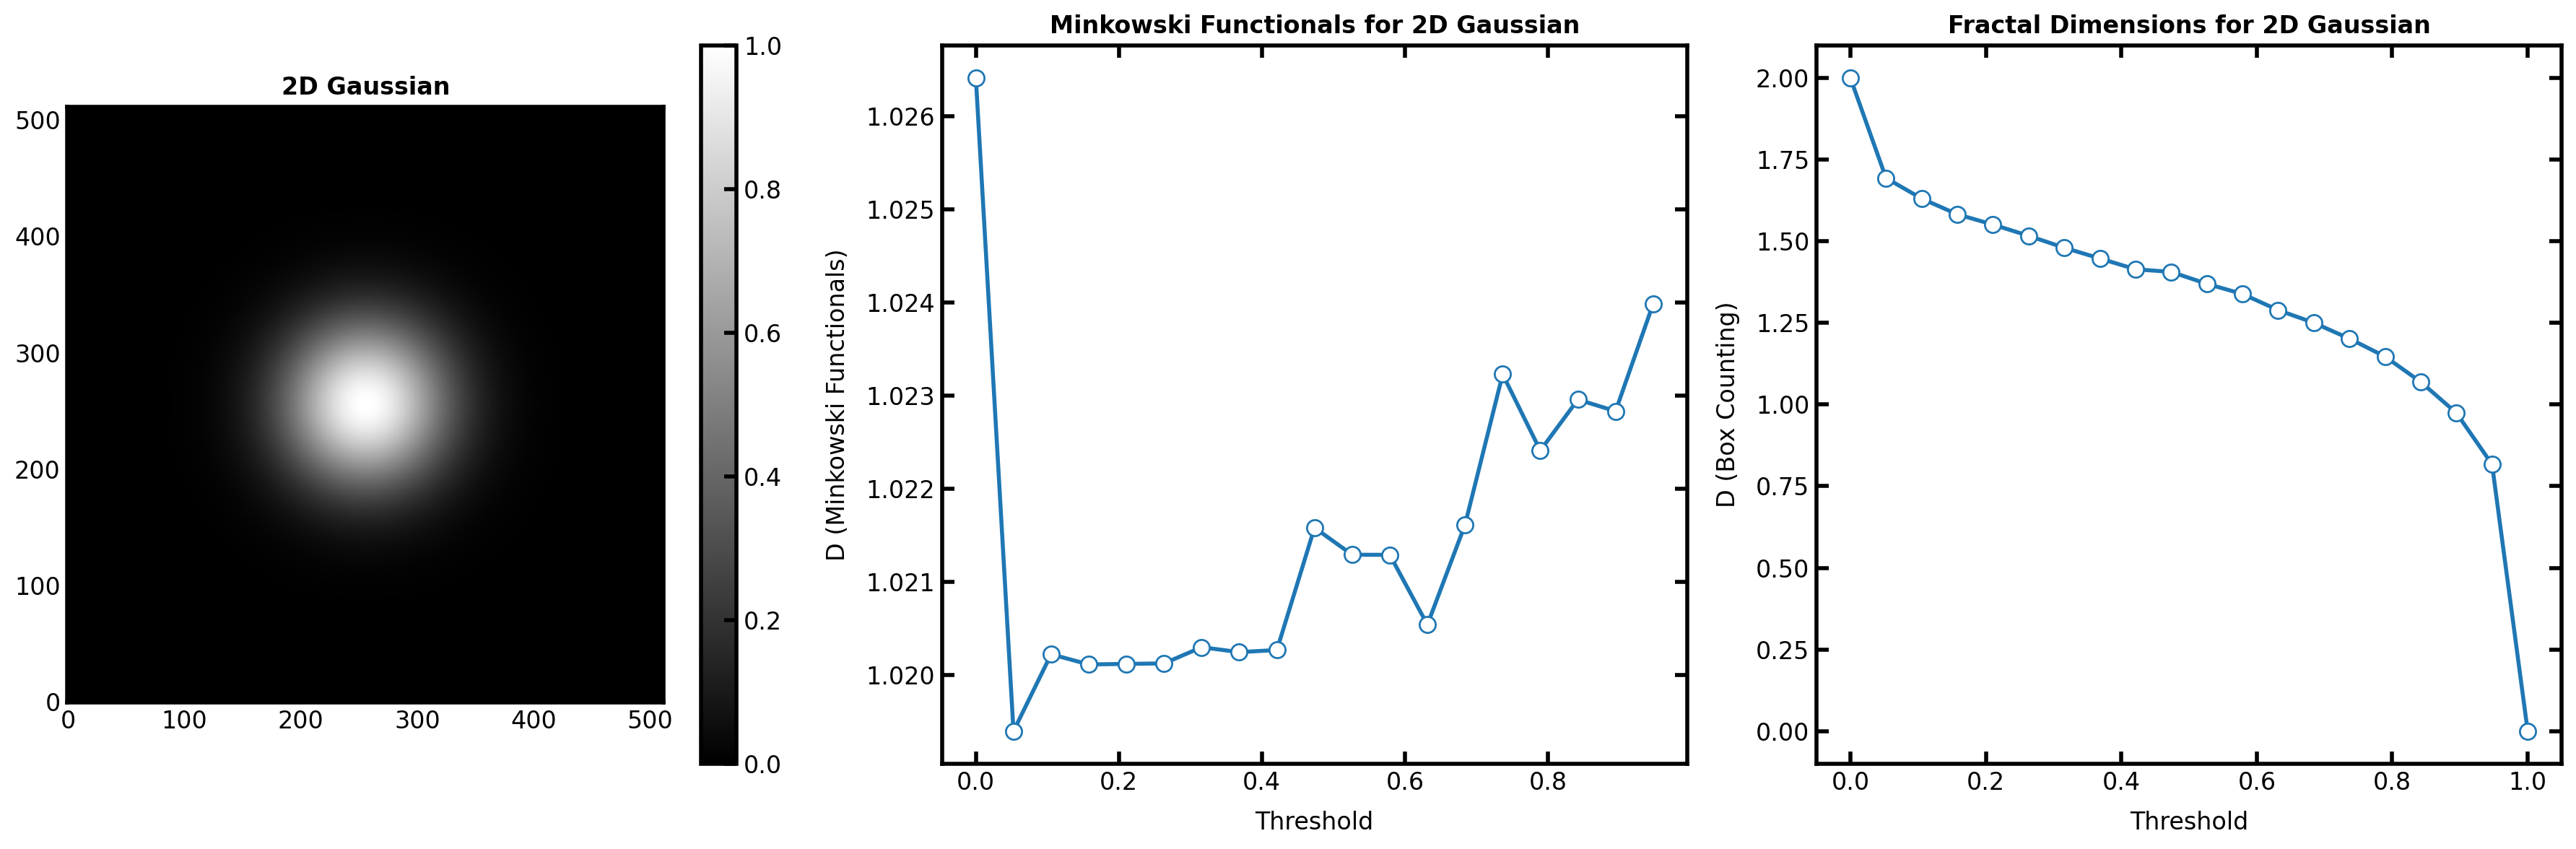

In [4]:
def intercept_corrected_minkowski_functionals(data, threshold_min=1e20, threshold_max=1e22, thresholds=None):
    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    # Store Minkowski Functional values
    areas = []
    perimeters = []
    euler_chars = []

    # Process each threshold
    for threshold in thresholds:
        # Create binary mask
        mask = data >= threshold

        # Compute Area (v0)
        area = np.sum(mask)
        areas.append(area)

        # Compute Perimeter (v1) with correction for the intercept
        perim = perimeter(mask)
        perimeters.append(perim)

        # Compute Euler Characteristic (v2)
        euler_char = euler_number(mask)
        euler_chars.append(euler_char)

    # Convert to log scale for fractal dimension analysis
    log_areas = np.log10(areas)
    log_perimeters = np.log10(perimeters)

    # Fit a linear model to obtain the intercept
    # Filter out zero or negative areas and perimeters to avoid log10 issues
    valid_indices = (log_areas > -np.inf) & (log_perimeters > -np.inf)
    filtered_log_areas = log_areas[valid_indices]
    filtered_log_perimeters = log_perimeters[valid_indices]

    # Fit a linear model to obtain the intercept
    coefficients = np.polyfit(filtered_log_perimeters, filtered_log_areas, 1)
    slope, intercept = coefficients

    # Plot log_areas vs log_perimeters and the linear fit
    plt.figure(figsize=(8, 6))
    plt.scatter(log_perimeters, log_areas, label="Data Points", color="blue")
    plt.plot(log_perimeters, slope * log_perimeters + intercept, label=f"Fit: y = {slope:.2f}x + {intercept:.2f}", color="red")
    plt.xlabel("log(Perimeters)")
    plt.ylabel("log(Areas)")
    plt.title("Log-Log Plot of Areas vs Perimeters with Linear Fit")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Version 1
    D = 2 * (log_perimeters ) / (log_areas - intercept)

    # Version 2 (does not work for gaussian)
    # D = 2 * (log_perimeters + intercept) / (log_areas)

    print(D)

    return {
        "thresholds": thresholds,
        "areas": areas,
        "perimeters": perimeters,
        "euler_chars": euler_chars,
        "fractal_dimension": D
    }

# Generate a single 2D Gaussian
shape = (512, 512)
center = (256, 256)  # Center of the Gaussian
sigma = 50  # Standard deviation of the Gaussian
gaussian = generate_2d_gaussian(shape, center, sigma)

# Calculate Minkowski functionals for the Gaussian
gaussian_thresholds = np.linspace(np.min(gaussian), np.max(gaussian), 20)
gaussian_results = intercept_corrected_minkowski_functionals(gaussian, thresholds=gaussian_thresholds)

# Calculate fractal dimensions using box counting method
gaussian_fractal_dimensions_BC = []
for threshold in gaussian_thresholds:
    gaussian_fractal_dimensions_BC.append(box_counting(gaussian >= threshold))

show_shapes_results(gaussian, "2D Gaussian", gaussian_thresholds, gaussian_results, gaussian_fractal_dimensions_BC)

In [ ]:
# more shapes to test this on ...

# when is that the case? what would that tell us about the geometry of the object?
# then test it on real data, to check if that makes sense. It might still be the case that we should not account for k in the real data scencario (?)


## **3: Linearity Breaking: GRF**

An interesting example appears when analyzing a Gaussian Random Field (GRF). Instead of exhibiting a strict anticorrelation between the Minkowski Dimension and the Box Counting measure (as seen in the other examples), the GRF behaves differently. 

The overall shape of the PA curve is more symmetric, with a distinct maximum. Interestingly, the Box-Counting method provides always the same result for the GRF. It always follows the same pattern, transitioning from a dimension of approximately 2 down to near 0. This is also for me a bit hard to interpret, as the fractal dimension should be between 1 and 2. 

Trying to fit for the intercept is tricky, as the P-A diagram is not overall linear anymore, so one could only perform this analysis where the linearity holds. This is likely why the GRF behaves in a much different way than in the other case scenario. This does tell us that not every scenario behaves linearly, and hence not everywhere the PA Method is a good pick.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.measure import perimeter, euler_number

def standard_minkowski_functionals_2(data, threshold_min=1e20, threshold_max=1e22, thresholds=None):
    """
    Compute the standard Minkowski functionals (area, perimeter, Euler characteristic) 
    and fractal dimension for a given 2D dataset across a range of thresholds.

    Parameters:
    ----------
    data : numpy.ndarray
        A 2D array representing the map dataset for which Minkowski functionals are computed.
    threshold_min : float, optional
        The minimum threshold value for generating the binary masks. Default is 1e20.
    threshold_max : float, optional
        The maximum threshold value for generating the binary masks. Default is 1e22.
    thresholds : numpy.ndarray or None, optional
        An array of threshold values to use. If None, thresholds are generated 
        logarithmically between `threshold_min` and `threshold_max`.

    Returns:
    -------
    dict
        A dictionary containing the following keys:
        - "thresholds": The array of threshold values used.
        - "areas": The computed areas (v0) for each threshold.
        - "perimeters": The computed perimeters (v1) for each threshold.
        - "euler_chars": The computed Euler characteristics (v2) for each threshold.
        - "fractal_dimension": The computed fractal dimensions based on the log-log 
          relationship between area and perimeter.

    Notes:
    -----
    - Minkowski functionals are geometric measures used to describe the morphology 
      of structures in 2D or 3D datasets. 
    - The fractal dimension is derived from the relationship between the logarithm 
      of the perimeter and the logarithm of the area.
    - The relation D = (2 * log(perimeter)) / (log(area)) is used to compute the fractal dimension.
    """
    # If thresholds are not provided, generate them using a logarithmic scale
    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    # Store Minkowski Functional values
    areas = []
    perimeters = []
    euler_chars = []

    # Process each threshold
    for threshold in thresholds:
        # Create binary mask
        mask = data >= threshold

        # Compute Area (v0)
        area = np.sum(mask)
        areas.append(area)

        # Compute Perimeter (v1)
        mask_perim = perimeter(mask)
        perimeters.append(mask_perim)

        # Compute Euler Characteristic (v2)
        euler_char = euler_number(mask)
        euler_chars.append(euler_char)

    # Convert to log scale for fractal dimension analysis
    log_areas = np.log10(areas)
    log_perimeters = np.log10(np.array(perimeters))

    # Fit a linear model to log_areas and log_perimeters to retrieve D
    # valid_indices = (log_areas > -np.inf) & (log_perimeters > -np.inf)
    # filtered_log_areas = log_areas[valid_indices]
    # filtered_log_perimeters = log_perimeters[valid_indices]

    # Perform linear regression
    coefficients = np.polyfit(log_perimeters, log_areas, 1)
    slope, intercept = coefficients
    # Calculate correlation coefficient between log_perimeters and log_areas
    corr_coef = np.corrcoef(log_perimeters, log_areas)[0, 1]
    print(f"Correlation coefficient: {corr_coef:.4f}")

    # Fractal dimension D is twice the slope
    m = 2/slope
    print(2/slope)

    D = (2 * log_perimeters) / (log_areas)

    # Estimate uncertainties
    sigma_A = np.sqrt(areas)  # rough Poisson error
    sigma_P = 0.5 * np.sqrt(perimeters)  # rough guess; adjust based on your system

    # Convert to np arrays
    areas = np.array(areas)
    perimeters = np.array(perimeters)

    # Partial derivatives
    dD_dP = 2 / (np.log(10) * perimeters * log_areas)
    dD_dA = -2 * log_perimeters / (np.log(10) * areas * log_areas**2)

    # Propagate uncertainties
    sigma_D = np.sqrt((dD_dP * sigma_P)**2 + (dD_dA * sigma_A)**2)

    plt.figure(figsize=(8, 6))
    plt.scatter(log_perimeters, log_areas, label="Data Points", color="blue")
    plt.plot(log_perimeters, slope * log_perimeters + intercept, label=f"Fit with D = {2/slope:.2f}", color="red")
    plt.xlabel("log(P)", fontsize=20)
    plt.ylabel("log(A)", fontsize=20)
    # plt.title("Log-Log Plot of Areas vs Perimeters with Linear Fit")
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.show()

    return {
        "thresholds": thresholds,
        "areas": areas,
        "perimeters": perimeters,
        "euler_chars": euler_chars,
        "fractal_dimension": D,
        "sigma_D": sigma_D
    }

Correlation coefficient: 0.9978
1.825922179904694


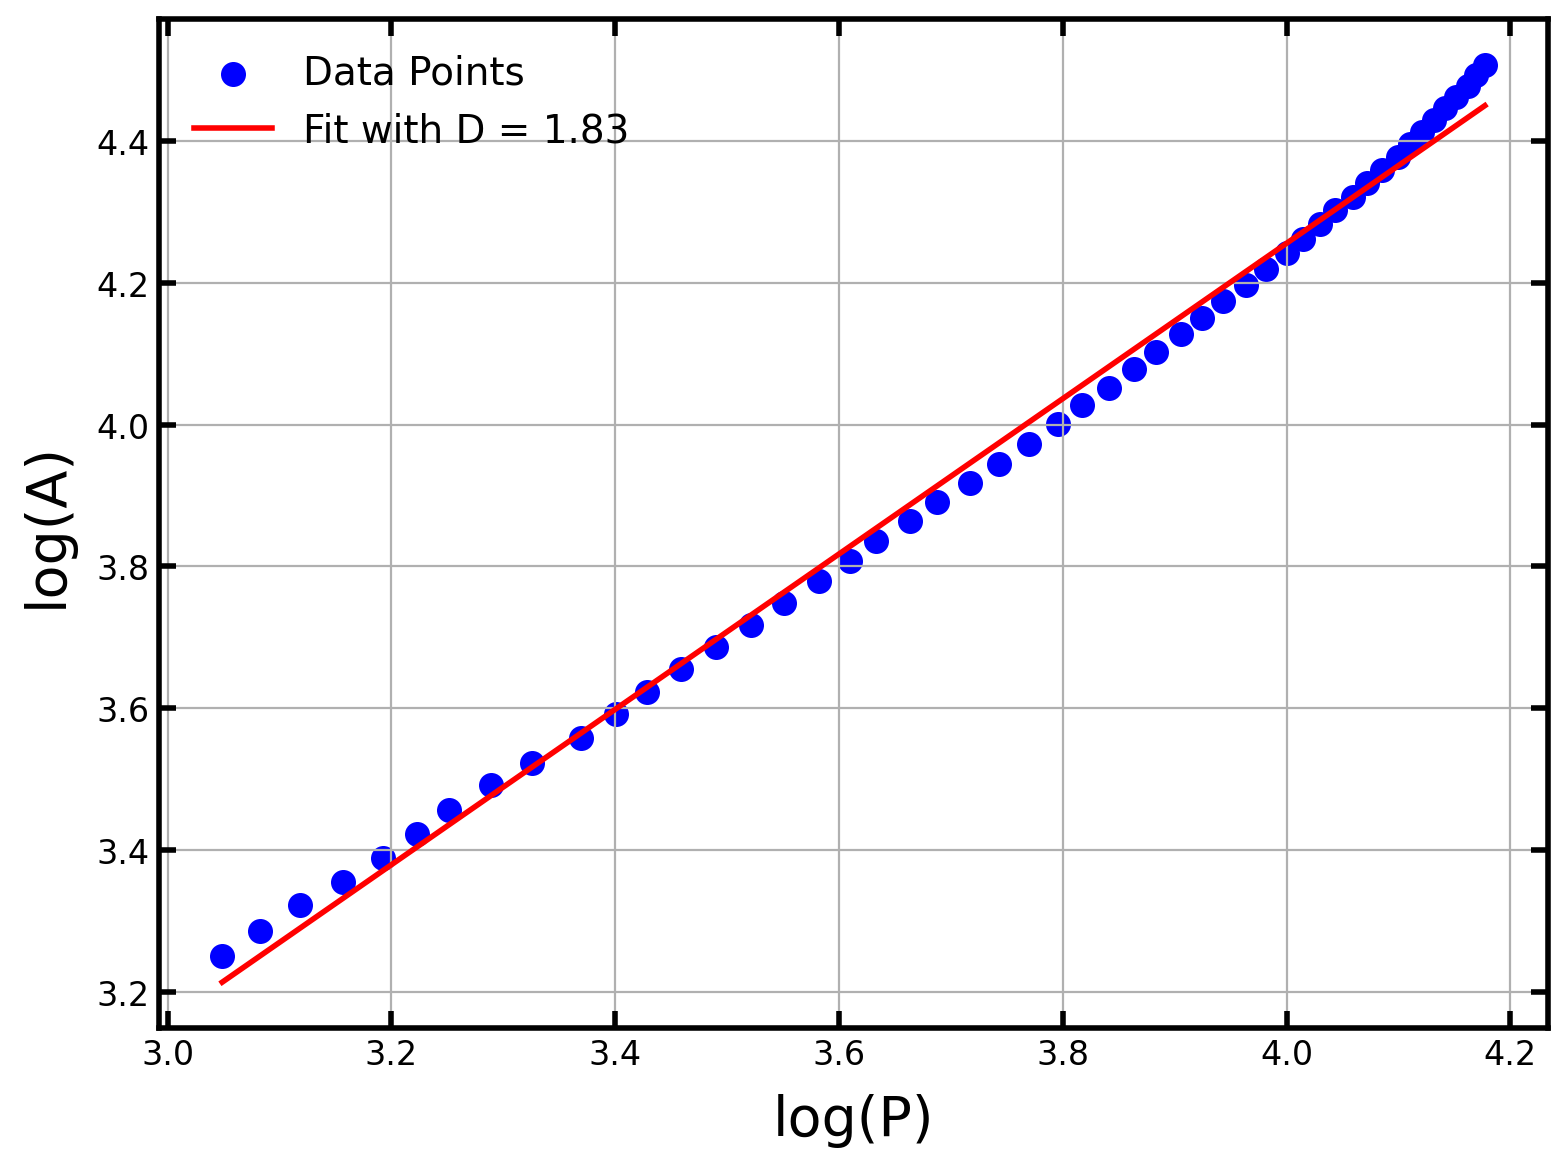

In [14]:
size = 256 
a = -2.0     # Power spectrum exponent
field, field_CZ_eval = generate_gaussian_random_field(size, a)

# plot_GRF(field, field_CZ_eval, size)

GRF_thresholds = np.linspace(0, 2, 50)
GRF_results = standard_minkowski_functionals_2(field.astype(float), thresholds=GRF_thresholds)


# GRF_fractal_dimensions_BC = []
# for threshold in GRF_thresholds:
#     GRF_fractal_dimensions_BC.append(box_counting(field >= threshold))

# show_shapes_results(field, "Gaussian Random Field", GRF_thresholds, GRF_results, GRF_fractal_dimensions_BC)

# plt.scatter(GRF_results["perimeters"], GRF_results["areas"])

# 📌**Conclusions: Which formula is to be used then?**

---

With this simple set of simulations, we have learned a few aspects of the PA relation:

1. The PA relation *always* shows an anti-correlation with the Box-Counting Method, yet both describe similar structural properties.
2. The PA relation is rotation and scale invariant, and describes more the border complexity of the shape.
3. Fitting for the proportionality constant $k$ is an important aspect of the routine.
4. However, not all scenarios behave linearly: the PA relation cannot be used globally.

We can use what we learned here interpret our results:

* **Smooth, sausage-like, less space-filling structures tend toward $D = 2$** with the PA method.
  These have long, coherent borders with minimal surface roughness, leading to a perimeter that increases roughly linearly with area.

* **Rough, hairy caterpillar-like, space-filling structures tend toward $D = 1$**.
  These have irregular, highly contorted borders that expand more slowly with area, leading to a sublinear perimeter-area relationship.

More tests are run in `Simulations_PA.ipynb`. (WIP)

---

## **Sausage/Hairy Caterpillar Dichotomy**

This dichotomy reflects two structural extremes observed in interstellar clouds and their substructures. "Sausages" represent compact, elongated structures with smooth perimeters—perhaps filaments or clumps. "Hairy caterpillars," by contrast, represent turbulent regions with significant substructure and fine-scale roughness along their boundaries.

This terminology helps us qualitatively classify clouds based on their perimeter-area scaling and understand the physical processes shaping them—e.g., gravitational collapse vs. turbulence-driven fragmentation.

---

## **Working with real data**

When working with actual observational maps:

* Beam convolution and resolution limits affect both perimeter and area measurements, potentially flattening the PA relation.
* Noise and thresholding play a key role—especially in defining what counts as the "border" of a structure.
* In such cases, it's crucial to test how robust the PA-derived fractal dimension $D$ is across different intensity thresholds and map resolutions.
* Calibration with simulations (e.g., via synthetic observations) helps to interpret the physical meaning of the inferred $D$ from real data.

---

## **Sublinearity: what does it mean?**

Going from $D = 1$ to $D = 2$, we also switch from a linear relation of Perimeter–Area to a sublinear one. This sublinearity implies that as area increases, perimeter grows less than proportionally, which is expected if the structure "fills" space more uniformly. Thus, sublinearity in the PA relation can be interpreted as a signature of increasing spatial coherence or regularity.


## A Line: An Infinetly Complex Shape?

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import linregress

def koch_snowflake(order, scale=1.0):
    # Initial triangle
    def segment(p1, p2):
        return np.array([p1, p2])

    def koch_curve(points):
        new_points = []
        for i in range(len(points) - 1):
            p1 = points[i]
            p2 = points[i + 1]
            delta = p2 - p1
            one_third = p1 + delta / 3
            two_third = p1 + 2 * delta / 3

            # Rotate to get peak of the triangle
            angle = np.pi / 3
            dx, dy = delta / 3
            peak = one_third + np.array([
                dx * np.cos(angle) - dy * np.sin(angle),
                dx * np.sin(angle) + dy * np.cos(angle)
            ])
            new_points += [p1, one_third, peak, two_third]
        new_points.append(points[-1])
        return np.array(new_points)

    # Start with equilateral triangle
    height = sqrt(3) / 2 * scale
    p1 = np.array([0, 0])
    p2 = np.array([scale, 0])
    p3 = np.array([scale / 2, height])
    points = np.array([p1, p2, p3, p1])

    for _ in range(order):
        points = koch_curve(points)

    return points

# Compute area and perimeter for increasing orders
orders = range(1, 10)
areas = []
perimeters = []

for order in orders:

    pts = koch_snowflake(order, scale=1.0)
    results = standard_minkowski_functionals(pts, thresholds=np.linspace(0.05, 1, 20))
    print(results["fractal_dimension"])


# Log-log regression

# Plot
# plt.figure(figsize=(8, 6))
# plt.plot(log_areas, log_perimeters, 'o-', label='Data')
# plt.plot(log_areas, slope * log_areas + intercept, 'r--', label=f'Fit: D ≈ {fractal_dimension:.4f}')
# plt.xlabel('log(Area)')
# plt.ylabel('log(Perimeter)')
# plt.title('Fractal Dimension from Perimeter-Area Scaling (Koch Snowflake)')
# plt.legend()
# plt.grid(True)
# plt.show()


[2.01464895 2.01464895 2.01464895 2.0234817  2.0234817  1.95092998
 1.85160352 1.85160352 1.85160352 1.85160352 1.47671277 0.
 0.               -inf       -inf       -inf       -inf       -inf
       -inf       -inf]
[2.00318691 1.99530962 1.98897489 1.99566262 1.99557811 1.98107772
 1.96836654 1.97541349 1.978756   1.94009612 1.9216064  1.88526213
 1.81709353 1.67365767 1.62301513 1.54795206 0.               -inf
       -inf       -inf]
[1.99824658 1.99780196 1.99814159 1.99794955 1.99714477 1.99655781
 1.98903225 1.99578111 1.98803463 1.9825207  1.97645089 1.98110736
 1.9079722  1.96047061 1.94471406 1.92609098 1.73364288 1.77124375
 0.               -inf]
[1.99968557 1.99955974 1.99882107 1.99970338 1.99942301 1.99931994
 1.99760631 1.99917558 1.99637096 1.99407528 1.99323695 1.99447057
 1.97579452 1.99272395 1.99038724 1.97339731 1.94371792 1.97027302
 1.76187796       -inf]
[1.99979171 1.99990789 1.99962829 1.99983077 1.99988001 1.99985924
 1.99941322 1.99982964 1.99905054 1.99802